In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import regex as re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
seed = 42

import warnings
warnings.filterwarnings('ignore')

In [108]:
df_train = pd.read_csv('laptops_train.csv')
df_test = pd.read_csv('laptops_test.csv')

In [109]:
df = pd.concat([df_train, df_test])

df_train, df_test = train_test_split(df, test_size = 0.20)

print(df_train.shape, df_test.shape)

df_train.reset_index(drop = True, inplace = True)
df_test.reset_index(drop = True, inplace = True)

(1041, 13) (261, 13)


In [110]:
df_train.head()

,Manufacturer,Model Name,Category,Screen Size,Screen,CPU,RAM,Storage,GPU,Operating System,Operating System Version,Weight,Price
0,Toshiba,Satellite Pro,Notebook,"15.6""",IPS Panel Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8GB,256GB SSD,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0
1,Dell,XPS 15,Notebook,"15.6""",4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,1TB SSD,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0
2,Dell,Precision M5520,Workstation,"15.6""",4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0
3,Acer,Aspire 3,Notebook,"15.6""",1366x768,Intel Celeron Dual Core N3350 2GHz,4GB,500GB HDD,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0
4,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 2.0GHz,8GB,256GB SSD,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0


In [111]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Manufacturer              1041 non-null   object 
 1   Model Name                1041 non-null   object 
 2   Category                  1041 non-null   object 
 3   Screen Size               1041 non-null   object 
 4   Screen                    1041 non-null   object 
 5   CPU                       1041 non-null   object 
 6   RAM                       1041 non-null   object 
 7    Storage                  1041 non-null   object 
 8   GPU                       1041 non-null   object 
 9   Operating System          1041 non-null   object 
 10  Operating System Version  905 non-null    object 
 11  Weight                    1041 non-null   object 
 12  Price                     1041 non-null   float64
dtypes: float64(1), object(12)
memory usage: 105.9+ KB


In [112]:
df_train.describe()

,Price
count,1.041000e+03
mean,9.923826e+06
std,6.211144e+06
min,1.547208e+06
25%,5.326219e+06
50%,8.527428e+06
75%,1.311570e+07
max,5.423231e+07


In [113]:
df_train = df_train.rename(columns = str.lower)
df_test = df_test.rename(columns = str.lower)

In [114]:
df.columns

Index(['Manufacturer', 'Model Name', 'Category', 'Screen Size', 'Screen',
       'CPU', 'RAM', ' Storage', 'GPU', 'Operating System',
       'Operating System Version', 'Weight', 'Price'],
      dtype='object')

In [115]:
df_train[df_train.duplicated()]

,manufacturer,model name,category,screen size,screen,cpu,ram,storage,gpu,operating system,operating system version,weight,price
313,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,"15.6""",1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows,10,2.19kg,6793488.00
355,HP,Stream 11-Y000na,Netbook,"11.6""",1366x768,Intel Celeron Dual Core N3060 1.6GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows,10,1.17kg,1858428.00
386,Lenovo,IdeaPad 100S-14IBR,Notebook,"14.0""",1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows,10,1.5kg,2036268.00
423,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,"14.0""",IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows,10,1.8kg,5673096.00
488,Dell,Inspiron 3567,Notebook,"15.6""",1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,NaN,2.3kg,7166863.08
554,Dell,Inspiron 3567,Notebook,"15.6""",1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,NaN,2.3kg,7166863.08
579,Asus,X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce,Notebook,"15.6""",1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows,10,2.2kg,6405085.44
620,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,"15.6""",1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows,10,2.19kg,6793488.00
691,Lenovo,IdeaPad Y700-15ISK,Notebook,"15.6""",IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows,10,2.6kg,7993908.00
764,Lenovo,IdeaPad 100S-14IBR,Notebook,"14.0""",1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows,10,1.5kg,2036268.00


## In the screen resolution column, there are included multiple useful informations.
-Screen type
-Resolution
-Touchscreen

We will separate this 3 informations in 3 different columns.

In [116]:
df['Screen'].value_counts()

Screen
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x1440        

In [117]:
df_train['resolution'] = df_train['screen'].str.extract(r'(\d+x\d+)')
df_test['resolution'] = df_test['screen'].str.extract(r'(\d+x\d+)')
df_train['screen_type'] = df_train['screen'].replace(r'(\d+x\d+)','', regex = True)
df_test['screen_type'] = df_test['screen'].replace(r'(\d+x\d+)','', regex = True)
df_train['screen_type'] = df_train['screen_type'].replace(r'(Full HD|Quad HD|Quad HD|\+|/|4K Ultra HD)','', regex = True)
df_test['screen_type'] = df_test['screen_type'].replace(r'(Full HD|Quad HD|Quad HD|\+|/|4K Ultra HD)','', regex = True)


In [118]:
df_train['screen_type']

0                     IPS Panel  
1                    Touchscreen 
2                    Touchscreen 
3                                
4       IPS Panel Retina Display 
                  ...            
1036                             
1037                             
1038                             
1039                             
1040     IPS Panel   Touchscreen 
Name: screen_type, Length: 1041, dtype: object

In [119]:
df_train['touchscreen'] = df_train['screen_type'].str.extract(r'(Touchscreen)')
df_train['screen_type'] = df_train['screen_type'].replace(r'(Touchscreen)','', regex = True)

df_test['touchscreen'] = df_test['screen_type'].str.extract(r'(Touchscreen)')
df_test['screen_type'] = df_test['screen_type'].replace(r'(Touchscreen)','', regex = True)


In [120]:
df_train['touchscreen'] = df_train['touchscreen'].replace('Touchscreen', 1)
df_train['touchscreen'] = df_train['touchscreen'].replace(np.nan, 0)

df_test['touchscreen'] = df_test['touchscreen'].replace('Touchscreen', 1)
df_test['touchscreen'] = df_test['touchscreen'].replace(np.nan, 0)

In [121]:
df_train['screen_type'] = df_train['screen_type'].replace(r' ','', regex = True)
df_test['screen_type'] = df_test['screen_type'].replace(r' ','', regex = True)

df_train['screen_type'].value_counts()

screen_type
                         750
IPSPanel                 277
IPSPanelRetinaDisplay     14
Name: count, dtype: int64

In [122]:
df_train['screen_type'] = df_train['screen_type'].replace(r'^\s*$', np.nan, regex = True)
df_test['screen_type'] = df_test['screen_type'].replace(r'^\s*$', np.nan, regex = True)

df_train['screen_type'].value_counts()

screen_type
IPSPanel                 277
IPSPanelRetinaDisplay     14
Name: count, dtype: int64

In [123]:
df_train.head()

,manufacturer,model name,category,screen size,screen,cpu,ram,storage,gpu,operating system,operating system version,weight,price,resolution,screen_type,touchscreen
0,Toshiba,Satellite Pro,Notebook,"15.6""",IPS Panel Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8GB,256GB SSD,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0,1920x1080,IPSPanel,0.0
1,Dell,XPS 15,Notebook,"15.6""",4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,1TB SSD,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0,3840x2160,NaN,1.0
2,Dell,Precision M5520,Workstation,"15.6""",4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0,3840x2160,NaN,1.0
3,Acer,Aspire 3,Notebook,"15.6""",1366x768,Intel Celeron Dual Core N3350 2GHz,4GB,500GB HDD,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0,1366x768,NaN,0.0
4,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 2.0GHz,8GB,256GB SSD,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0


In [124]:
df_train = df_train.drop('screen', axis = 1)
df_test = df_test.drop('screen', axis = 1)

<Axes: >

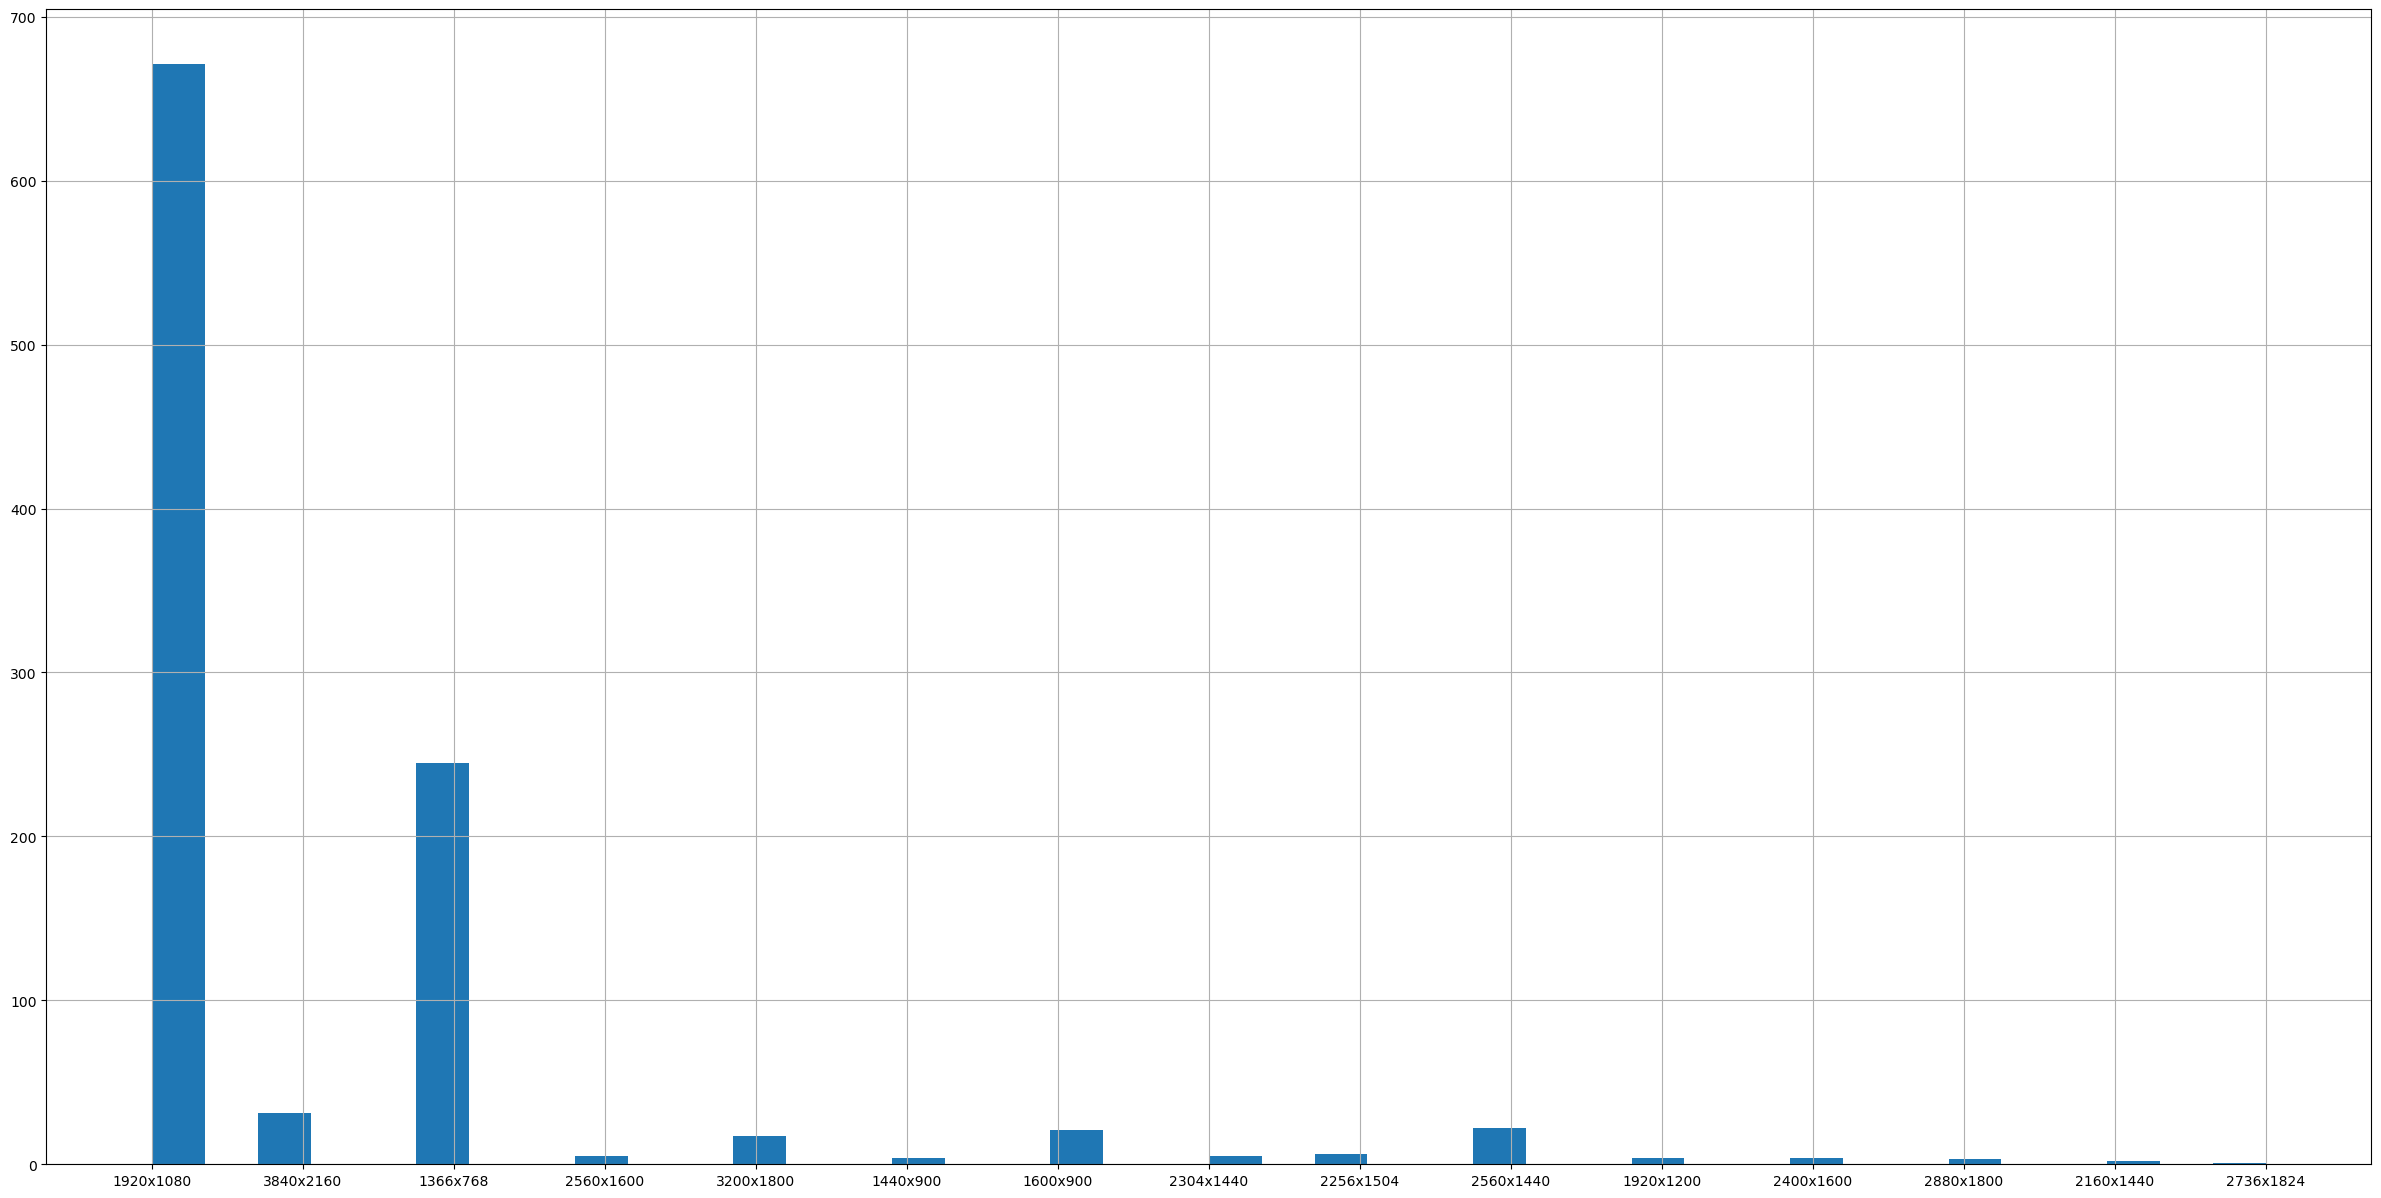

In [125]:
df_train['resolution'].hist(bins = 40, figsize= (30, 15))

In [126]:
df_train['screen_type'].value_counts()

screen_type
IPSPanel                 277
IPSPanelRetinaDisplay     14
Name: count, dtype: int64

<Axes: >

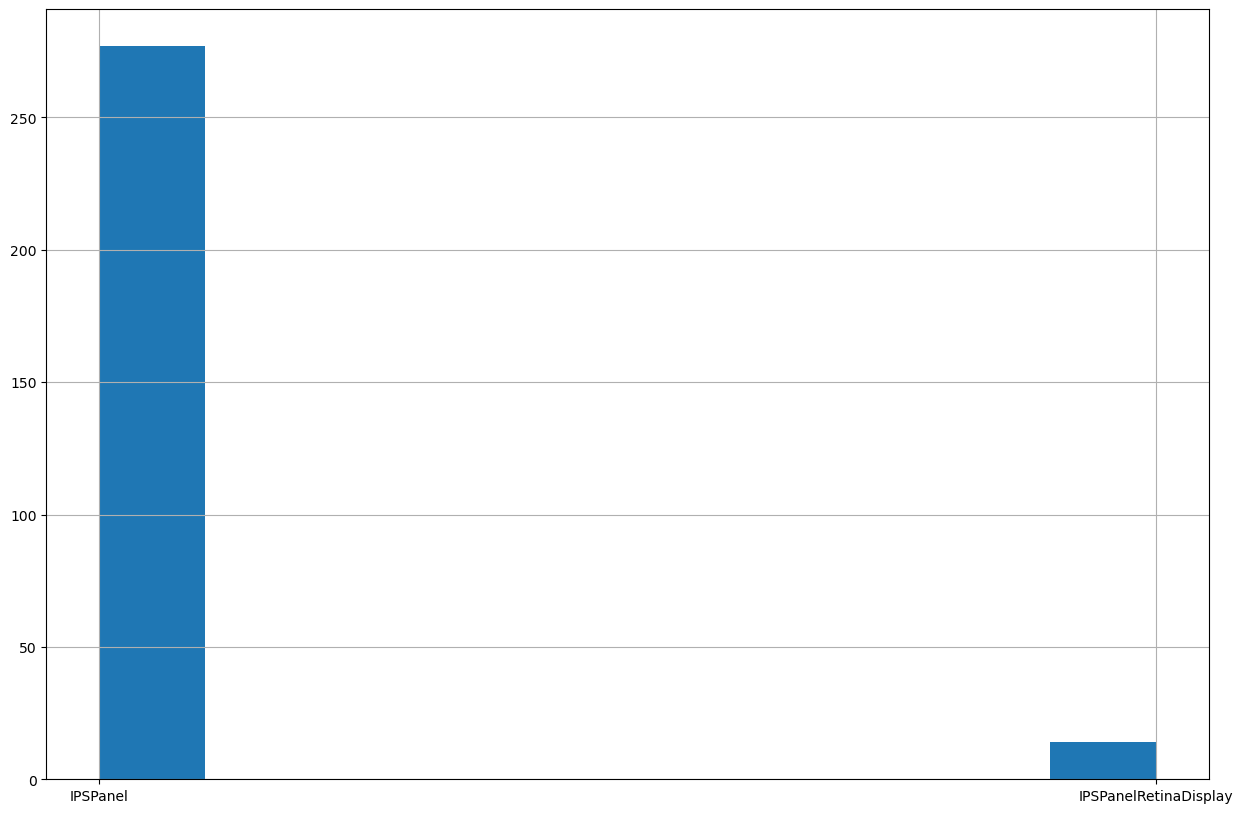

In [127]:
df_train['screen_type'].hist(figsize= (15, 10))

In [128]:
df_train['touchscreen'].value_counts()

touchscreen
0.0    895
1.0    146
Name: count, dtype: int64

Everything looks okay.
    
## Now we will perform the same feature engineering process to CPU column


In [129]:
df_train['cpu'].value_counts()

cpu
Intel Core i5 7200U 2.5GHz       159
Intel Core i7 7700HQ 2.8GHz      116
Intel Core i7 7500U 2.7GHz       103
Intel Core i7 8550U 1.8GHz        62
Intel Core i5 8250U 1.6GHz        54
                                ... 
AMD A6-Series 9220 2.9GHz          1
Intel Core i5 2.0GHz               1
AMD A6-Series 7310 2GHz            1
Intel Core M M3-6Y30 0.9GHz        1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 109, dtype: int64

In [130]:
df_train['cpu_freq'] = df_train['cpu'].str.extract(r'(\d+(?:\.\d+)?GHz)') 
df_test['cpu_freq'] = df_test['cpu'].str.extract(r'(\d+(?:\.\d+)?GHz)') 

In [131]:
df_train['cpu_freq'].value_counts()

cpu_freq
2.5GHz     237
2.8GHz     131
2.7GHz     128
1.6GHz     104
2.6GHz      66
1.8GHz      66
2.3GHz      63
2GHz        51
2.4GHz      45
1.1GHz      41
2.9GHz      19
2.0GHz      17
3GHz        12
1.2GHz      11
1.5GHz      10
2.2GHz      10
1.44GHz      7
1.3GHz       5
2.1GHz       3
0.9GHz       3
3.6GHz       3
2.50GHz      2
1.9GHz       1
2.70GHz      1
3.1GHz       1
1.92GHz      1
1.60GHz      1
3.2GHz       1
1.0GHz       1
Name: count, dtype: int64

Since all the frequencies are in GHz, we can now simply remove 'GHz' and add it to the column name, such that the column can become numerical



In [132]:
df_train['cpu_freq'] = df_train['cpu_freq'].str.replace('GHz', '')
df_train.rename(columns = {'cpu_freq': 'cpu_freq(GHz)'}, inplace = True)

df_test['cpu_freq'] = df_test['cpu_freq'].str.replace('GHz', '')
df_test.rename(columns = {'cpu_freq': 'cpu_freq(GHz)'}, inplace = True)

In [133]:
df_train['cpu_freq(GHz)'] = df_train['cpu_freq(GHz)'].astype(float)

In [134]:
df_train['cpu']= df_train['cpu'].str.replace(r'(\d+(?:\.\d+)?GHz)', '', regex = True)
df_test['cpu']= df_test['cpu'].str.replace(r'(\d+(?:\.\d+)?GHz)', '', regex = True)


In [135]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram,storage,gpu,operating system,operating system version,weight,price,resolution,screen_type,touchscreen,cpu_freq(GHz)
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8GB,256GB SSD,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0,1920x1080,IPSPanel,0.0,2.5
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16GB,1TB SSD,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0,3840x2160,NaN,1.0,2.8
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8GB,256GB SSD,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0,3840x2160,NaN,1.0,2.8
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4GB,500GB HDD,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0,1366x768,NaN,0.0,2.0
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8GB,256GB SSD,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0,2.0


## RAM
We will remove GB from each row and add it in the column name instead.

In [136]:
df_train['ram'] = df_train['ram'].str.replace('GB', '')
df_test['ram'] = df_test['ram'].str.replace('GB', '')
df_train.rename(columns = {'ram': 'ram(GB)'}, inplace = True)
df_test.rename(columns = {'ram': 'ram(GB)'}, inplace = True)
df_train['ram(GB)'] = df_train['ram(GB)'].astype(float)
df_test['ram(GB)'] = df_test['ram(GB)'].astype(float)

In [137]:
df_train.head(10)

,manufacturer,model name,category,screen size,cpu,ram(GB),storage,gpu,operating system,operating system version,weight,price,resolution,screen_type,touchscreen,cpu_freq(GHz)
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,256GB SSD,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0,1920x1080,IPSPanel,0.0,2.5
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,1TB SSD,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0,3840x2160,NaN,1.0,2.8
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,256GB SSD,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0,3840x2160,NaN,1.0,2.8
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,500GB HDD,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0,1366x768,NaN,0.0,2.0
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,256GB SSD,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0,2.0
5,Asus,ZenBook Pro,Ultrabook,"15.6""",Intel Core i7 7700HQ,16.0,512GB SSD,Nvidia GeForce GTX 1050 Ti,Windows,10,1.8kg,17632836.0,1920x1080,NaN,0.0,2.8
6,HP,EliteBook 850,Notebook,"15.6""",Intel Core i5 6300U,8.0,256GB SSD,Intel HD Graphics 520,Windows,10,1.84kg,16894800.0,1920x1080,NaN,0.0,2.4
7,Lenovo,Thinkpad X270,Ultrabook,"12.5""",Intel Core i7 7500U,8.0,256GB SSD,Intel HD Graphics 620,Windows,10,1.36kg,14084928.0,1920x1080,IPSPanel,0.0,2.7
8,Acer,Aspire E5-575,Notebook,"15.6""",Intel Core i5 7200U,6.0,1TB HDD,Intel HD Graphics 620,Windows,10,2.23kg,4881708.0,1366x768,NaN,0.0,2.5
9,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,"11.6""",Intel Celeron Dual Core 3205U,2.0,32GB SSD,Intel HD Graphics,Chrome OS,NaN,1.3kg,1547208.0,1366x768,NaN,0.0,1.5


We can extract lots of informations from this column. We can see that some laptops have 2 hard drives, there are 4 differnt types of disks: 'SSD', ''HDD', 'Hybrid' and 'Flash Storage'. We will create new columns to include all these information.

In [138]:
df_train[' storage'].value_counts()

 storage
256GB SSD                        316
1TB HDD                          186
500GB HDD                        111
512GB SSD                         91
128GB SSD +  1TB HDD              76
256GB SSD +  1TB HDD              62
128GB SSD                         61
32GB Flash Storage                31
512GB SSD +  1TB HDD              13
2TB HDD                           12
64GB Flash Storage                10
1TB SSD                            9
256GB Flash Storage                8
256GB SSD +  2TB HDD               8
1TB Hybrid                         8
16GB Flash Storage                 7
1GB SSD                            5
32GB SSD                           5
128GB Flash Storage                4
16GB SSD                           3
256GB SSD +  500GB HDD             2
512GB SSD +  2TB HDD               1
256GB SSD +  256GB SSD             1
32GB HDD                           1
512GB SSD +  1TB Hybrid            1
1TB SSD +  1TB HDD                 1
512GB Flash Storage          

In [139]:
df_train['storage_1'] = df_train[' storage']
df_test['storage_1'] = df_test[' storage']

In [140]:
# we transform drive capacity to GB
df_train['storage_1'] = df_train['storage_1'].str.replace('1.0TB','1TB', regex = True)
df_train['storage_1'] = df_train['storage_1'].str.replace('1TB','1000GB')
df_train['storage_1'] = df_train['storage_1'].str.replace('2TB','2000GB')
df_train['storage_1'] = df_train['storage_1'].str.replace('GB','')
df_train['storage_1'].value_counts()

df_test['storage_1'] = df_test['storage_1'].str.replace('1.0TB','1TB', regex = True)
df_test['storage_1'] = df_test['storage_1'].str.replace('1TB','1000GB')
df_test['storage_1'] = df_test['storage_1'].str.replace('2TB','2000GB')
df_test['storage_1'] = df_test['storage_1'].str.replace('GB','')

In [141]:
df_train['storage_2'] = df_train['storage_1'].str.replace(r' ','')
df_test['storage_2'] = df_test['storage_1'].str.replace(r' ','')

df_train['storage_2'].value_counts()

storage_2
256SSD                    316
1000HDD                   186
500HDD                    111
512SSD                     91
128SSD+1000HDD             76
256SSD+1000HDD             62
128SSD                     61
32FlashStorage             31
512SSD+1000HDD             13
2000HDD                    12
64FlashStorage             10
1000SSD                     9
256FlashStorage             8
256SSD+2000HDD              8
1000Hybrid                  8
16FlashStorage              7
1SSD                        5
32SSD                       5
128FlashStorage             4
16SSD                       3
256SSD+500HDD               2
512SSD+2000HDD              1
256SSD+256SSD               1
32HDD                       1
512SSD+1000Hybrid           1
1000SSD+1000HDD             1
512FlashStorage             1
64FlashStorage+1000HDD      1
1000HDD+1000HDD             1
128HDD                      1
512SSD+512SSD               1
64SSD                       1
512SSD+256SSD               1


In [142]:
storage_1 = []
storage_2 = []

for i in df_train['storage_2']:
    if len(re.findall(r'\+', i)) == 1: 
        # Double drive
        one = re.findall(r'(\w+)', i)
        storage_1.append(one[0])
        storage_2.append(one[1])
    else: 
        # Single drive
        one = re.findall(r'(\w+)', i)
        storage_1.append(one[0])
        storage_2.append('NaN')

In [143]:
s1 = []
s2 = []

for i in df_test['storage_2']:
    if len(re.findall(r'\+',i)) == 1: 
        # Double drive
        one = re.findall(r'(\w+)', i)
        s1.append(one[0])
        s2.append(one[1])
    else: 
        # Single drive
        one = re.findall(r'(\w+)', i)
        s1.append(one[0])
        s2.append('NaN')

Now we have separated the drives into two lists. We will now create two more lists that will contain the memory types.

In [144]:
storage_1_gb = []
storage_1_type = []
for i in storage_1:
    storage_1_type.append(re.findall(r'(\D\w+)', i)[0])
    storage_1_gb.append(re.findall(r'(\d+)', i)[0])


In [145]:
s1_gb = []
s1_type = []
for i in s1:
    s1_type.append(re.findall(r'(\D\w+)', i)[0])
    s1_gb.append(re.findall(r'(\d+)', i)[0])

In [146]:
storage_2_gb = []
storage_2_type = []
for i in storage_2:
    if i != 'NaN':
        storage_2_type.append(re.findall(r'(\D\w+)',i)[0])
        storage_2_gb.append(re.findall(r'(\d+)',i)[0])
    else:
        storage_2_type.append('NaN')
        storage_2_gb.append(0)

In [147]:
s2_gb = []
s2_type = []
for i in s2:
    if i != 'NaN':
        s2_type.append(re.findall(r'(\D\w+)',i)[0])
        s2_gb.append(re.findall(r'(\d+)',i)[0])
    else:
        s2_type.append('NaN')
        s2_gb.append(0)

In [148]:
df_train['storage_1_gb'] = storage_1_gb
df_train['storage_1_type'] = storage_1_type
df_train['storage_2_gb'] = storage_2_gb
df_train['storage_2_type'] = storage_2_type


df_test['storage_1_gb'] = s1_gb
df_test['storage_1_type'] = s1_type
df_test['storage_2_gb'] = s2_gb
df_test['storage_2_type'] = s2_type

In [149]:
df_train['storage_1_gb'] = df_train['storage_1_gb'].astype(float)
df_train['storage_2_gb'] = df_train['storage_2_gb'].astype(float)

df_test['storage_1_gb'] = df_test['storage_1_gb'].astype(float)
df_test['storage_2_gb'] = df_test['storage_2_gb'].astype(float)

In [150]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram(GB),storage,gpu,operating system,operating system version,...,resolution,screen_type,touchscreen,cpu_freq(GHz),storage_1,storage_2,storage_1_gb,storage_1_type,storage_2_gb,storage_2_type
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,256GB SSD,Nvidia GeForce 930M,Windows,10,...,1920x1080,IPSPanel,0.0,2.5,256 SSD,256SSD,256.0,SSD,0.0,NaN
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,1TB SSD,Nvidia GeForce GTX 1050,Windows,10,...,3840x2160,NaN,1.0,2.8,1000 SSD,1000SSD,1000.0,SSD,0.0,NaN
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,256GB SSD,Nvidia Quadro M1200,Windows,10,...,3840x2160,NaN,1.0,2.8,256 SSD,256SSD,256.0,SSD,0.0,NaN
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,500GB HDD,Intel HD Graphics 500,Windows,10,...,1366x768,NaN,0.0,2.0,500 HDD,500HDD,500.0,HDD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,256GB SSD,Intel Iris Graphics 540,macOS,NaN,...,2560x1600,IPSPanelRetinaDisplay,0.0,2.0,256 SSD,256SSD,256.0,SSD,0.0,NaN


In [151]:
df_train = df_train.drop(['storage_1','storage_2',' storage'], axis = 1)
df_test = df_test.drop(['storage_1','storage_2',' storage'], axis = 1)

In [152]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram(GB),gpu,operating system,operating system version,weight,price,resolution,screen_type,touchscreen,cpu_freq(GHz),storage_1_gb,storage_1_type,storage_2_gb,storage_2_type
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0,1920x1080,IPSPanel,0.0,2.5,256.0,SSD,0.0,NaN
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0,3840x2160,NaN,1.0,2.8,1000.0,SSD,0.0,NaN
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0,3840x2160,NaN,1.0,2.8,256.0,SSD,0.0,NaN
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0,1366x768,NaN,0.0,2.0,500.0,HDD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0,2.0,256.0,SSD,0.0,NaN


In [153]:
df_train = df_train.replace({'NaN' : np.nan})
df_test = df_test.replace({'NaN' : np.nan})

In [154]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram(GB),gpu,operating system,operating system version,weight,price,resolution,screen_type,touchscreen,cpu_freq(GHz),storage_1_gb,storage_1_type,storage_2_gb,storage_2_type
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,Nvidia GeForce 930M,Windows,10,2.2kg,9274356.0,1920x1080,IPSPanel,0.0,2.5,256.0,SSD,0.0,NaN
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050,Windows,10,2.06kg,21331908.0,3840x2160,NaN,1.0,2.8,1000.0,SSD,0.0,NaN
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,Nvidia Quadro M1200,Windows,10,1.78kg,24115104.0,3840x2160,NaN,1.0,2.8,256.0,SSD,0.0,NaN
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,Intel HD Graphics 500,Windows,10,2.1kg,2961036.0,1366x768,NaN,0.0,2.0,500.0,HDD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,Intel Iris Graphics 540,macOS,NaN,1.37kg,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0,2.0,256.0,SSD,0.0,NaN


# Feature Engineering For Weight

In [155]:
df_train['weight'].value_counts()

weight
2.2kg     100
2.1kg      46
2.3kg      36
2.4kg      32
2kg        27
         ... 
2.99kg      1
0.99kg      1
3.6kg       1
1.59kg      1
1.12kg      1
Name: count, Length: 170, dtype: int64

In [156]:
df_train['weight'] = df_train['weight'].str.replace('kg', '')
df_train['weight'] = df_train['weight'].str.replace('s', '').astype(float)
df_test['weight'] = df_test['weight'].str.replace('kg', '')
df_test['weight'] = df_test['weight'].str.replace('s', '').astype(float)

In [157]:
df_train.rename(columns = {'weight': 'weight(kg)'}, inplace = True)
df_test.rename(columns = {'weight': 'weight(kg)'}, inplace = True)

In [158]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram(GB),gpu,operating system,operating system version,weight(kg),price,resolution,screen_type,touchscreen,cpu_freq(GHz),storage_1_gb,storage_1_type,storage_2_gb,storage_2_type
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,Nvidia GeForce 930M,Windows,10,2.20,9274356.0,1920x1080,IPSPanel,0.0,2.5,256.0,SSD,0.0,NaN
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050,Windows,10,2.06,21331908.0,3840x2160,NaN,1.0,2.8,1000.0,SSD,0.0,NaN
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,Nvidia Quadro M1200,Windows,10,1.78,24115104.0,3840x2160,NaN,1.0,2.8,256.0,SSD,0.0,NaN
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,Intel HD Graphics 500,Windows,10,2.10,2961036.0,1366x768,NaN,0.0,2.0,500.0,HDD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,Intel Iris Graphics 540,macOS,NaN,1.37,12617748.0,2560x1600,IPSPanelRetinaDisplay,0.0,2.0,256.0,SSD,0.0,NaN


# Feature Engineering for CPU and GPU Brands

In [159]:
df_train['cpu_brand'] = df_train['cpu'].str.extract(r'^(\w+)')
df_test['cpu_brand'] = df_test['cpu'].str.extract(r'^(\w+)')

df_train['cpu_brand'].value_counts()

cpu_brand
Intel      989
AMD         51
Samsung      1
Name: count, dtype: int64

In [160]:
df_train['gpu_brand'] = df_train['gpu'].str.extract(r'^(\w+)')
df_test['gpu_brand'] = df_test['gpu'].str.extract(r'^(\w+)')

df_train['gpu_brand'].value_counts()

gpu_brand
Intel     578
Nvidia    313
AMD       149
ARM         1
Name: count, dtype: int64

In [161]:
print(df_train['cpu'].value_counts())

cpu
Intel Core i5 7200U          162
Intel Core i7 7700HQ         117
Intel Core i7 7500U          103
Intel Core i3 6006U           63
Intel Core i7 8550U           62
                            ... 
AMD A10-Series A10-9620P       1
AMD A12-Series 9700P           1
Intel Xeon E3-1505M V6         1
AMD A6-Series 7310             1
Samsung Cortex A72&A53         1
Name: count, Length: 87, dtype: int64


In [162]:
def extract_cpu_features(df):
    # CPU Brand
    df['cpu_brand'] = df['cpu'].str.extract(r'(^\w+)', flags=re.IGNORECASE)

    # CPU Series
    df['cpu_series'] = df['cpu'].str.extract(
        r'(i[3579]|Ryzen\s?\d|Core M|Atom|Pentium|Celeron|A\d|E-Series)',
        flags=re.IGNORECASE
    )

    # CPU Generation (Updated with special cases)
    def get_cpu_generation(cpu_name):
        import re
        if pd.isnull(cpu_name):
            return None

        cpu_name = cpu_name.lower()

        # Intel Core i3, i5, i7, i9
        match = re.search(r'i\d[-\s]?(\d{4})', cpu_name, re.IGNORECASE)
        if match:
            return int(str(match.group(1))[0])  # First digit = generation

        # AMD Ryzen
        match = re.search(r'ryzen\s?\d\s(\d{4})', cpu_name, re.IGNORECASE)
        if match:
            return int(str(match.group(1))[0])

        # AMD A-Series or E-Series (e.g., A6-7310 or E-Series 6110)
        match = re.search(r'(a|e)-?series\s?(\d{4})', cpu_name, re.IGNORECASE)
        if match:
            return int(str(match.group(2))[0])  # First digit of 4-digit number

        # Intel Atom (e.g., Atom X5-Z8350 → take first digit after Z)
        match = re.search(r'atom.*?z?(\d)', cpu_name, re.IGNORECASE)
        if match:
            return int(match.group(1))

        # Pentium, Celeron, etc. (may not have generations)
        return None

    df['cpu_generation'] = df['cpu'].apply(get_cpu_generation)

    # CPU Type
    def get_cpu_type(cpu_name):
        if pd.isnull(cpu_name):
            return None
        if 'Core M' in cpu_name:
            return 'Core M'
        elif 'Atom' in cpu_name:
            return 'Atom'
        elif 'Pentium' in cpu_name:
            return 'Pentium'
        elif 'Celeron' in cpu_name:
            return 'Celeron'
        elif 'E-Series' in cpu_name:
            return 'E-Series'
        elif 'A' in cpu_name:
            return 'A-Series'
        else:
            return 'Standard'

    df['cpu_type'] = df['cpu'].apply(get_cpu_type)

    return df

# Apply to train and test
df_train = extract_cpu_features(df_train)
df_test = extract_cpu_features(df_test)

# Display result
print(df_train[['cpu', 'cpu_brand', 'cpu_series', 'cpu_generation', 'cpu_type']].head(10))


                              cpu cpu_brand cpu_series  cpu_generation  \
0            Intel Core i7 6500U      Intel         i7             6.0   
1           Intel Core i7 7700HQ      Intel         i7             7.0   
2           Intel Core i7 7700HQ      Intel         i7             7.0   
3  Intel Celeron Dual Core N3350      Intel    Celeron             NaN   
4                  Intel Core i5      Intel         i5             NaN   
5           Intel Core i7 7700HQ      Intel         i7             7.0   
6            Intel Core i5 6300U      Intel         i5             6.0   
7            Intel Core i7 7500U      Intel         i7             7.0   
8            Intel Core i5 7200U      Intel         i5             7.0   
9  Intel Celeron Dual Core 3205U      Intel    Celeron             NaN   

   cpu_type  
0  Standard  
1  Standard  
2  Standard  
3   Celeron  
4  Standard  
5  Standard  
6  Standard  
7  Standard  
8  Standard  
9   Celeron  


In [163]:
df_train.head(30)

,manufacturer,model name,category,screen size,cpu,ram(GB),gpu,operating system,operating system version,weight(kg),...,cpu_freq(GHz),storage_1_gb,storage_1_type,storage_2_gb,storage_2_type,cpu_brand,gpu_brand,cpu_series,cpu_generation,cpu_type
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,Nvidia GeForce 930M,Windows,10,2.20,...,2.5,256.0,SSD,0.0,NaN,Intel,Nvidia,i7,6.0,Standard
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050,Windows,10,2.06,...,2.8,1000.0,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,Nvidia Quadro M1200,Windows,10,1.78,...,2.8,256.0,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,Intel HD Graphics 500,Windows,10,2.10,...,2.0,500.0,HDD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,Intel Iris Graphics 540,macOS,NaN,1.37,...,2.0,256.0,SSD,0.0,NaN,Intel,Intel,i5,NaN,Standard
5,Asus,ZenBook Pro,Ultrabook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050 Ti,Windows,10,1.80,...,2.8,512.0,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard
6,HP,EliteBook 850,Notebook,"15.6""",Intel Core i5 6300U,8.0,Intel HD Graphics 520,Windows,10,1.84,...,2.4,256.0,SSD,0.0,NaN,Intel,Intel,i5,6.0,Standard
7,Lenovo,Thinkpad X270,Ultrabook,"12.5""",Intel Core i7 7500U,8.0,Intel HD Graphics 620,Windows,10,1.36,...,2.7,256.0,SSD,0.0,NaN,Intel,Intel,i7,7.0,Standard
8,Acer,Aspire E5-575,Notebook,"15.6""",Intel Core i5 7200U,6.0,Intel HD Graphics 620,Windows,10,2.23,...,2.5,1000.0,HDD,0.0,NaN,Intel,Intel,i5,7.0,Standard
9,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,"11.6""",Intel Celeron Dual Core 3205U,2.0,Intel HD Graphics,Chrome OS,NaN,1.30,...,1.5,32.0,SSD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron


In [164]:
def extract_gpu_features(df):
    # GPU Brand
    df['gpu_brand'] = df['gpu'].str.extract(r'(^\w+)', flags=re.IGNORECASE)

    # GPU Type (everything after brand)
    def get_gpu_type(gpu_name):
        if pd.isnull(gpu_name):
            return None
        gpu_name = gpu_name.strip()
        parts = gpu_name.split(' ', 1)  # Split only on first space
        if len(parts) > 1:
            return parts[1]
        else:
            return 'Integrated'  # fallback for simple names like 'Intel'
    
    df['gpu_type'] = df['gpu'].apply(get_gpu_type)

    # GPU Category: Dedicated vs Integrated
    def get_gpu_category(gpu_name):
        if pd.isnull(gpu_name):
            return None
        gpu_name = gpu_name.lower()
        if 'geforce' in gpu_name or 'radeon' in gpu_name:
            return 'Dedicated'
        elif 'hd graphics' in gpu_name or 'iris' in gpu_name or 'uhd' in gpu_name:
            return 'Integrated'
        else:
            return 'Integrated'  # fallback for unknowns

    df['gpu_category'] = df['gpu'].apply(get_gpu_category)

    return df

# Apply to train and test
df_train = extract_gpu_features(df_train)
df_test = extract_gpu_features(df_test)

# Display results
print(df_train[['gpu', 'gpu_brand', 'gpu_type', 'gpu_category']].head(10))


                          gpu gpu_brand             gpu_type gpu_category
0         Nvidia GeForce 930M    Nvidia         GeForce 930M    Dedicated
1     Nvidia GeForce GTX 1050    Nvidia     GeForce GTX 1050    Dedicated
2         Nvidia Quadro M1200    Nvidia         Quadro M1200   Integrated
3       Intel HD Graphics 500     Intel      HD Graphics 500   Integrated
4     Intel Iris Graphics 540     Intel    Iris Graphics 540   Integrated
5  Nvidia GeForce GTX 1050 Ti    Nvidia  GeForce GTX 1050 Ti    Dedicated
6       Intel HD Graphics 520     Intel      HD Graphics 520   Integrated
7       Intel HD Graphics 620     Intel      HD Graphics 620   Integrated
8       Intel HD Graphics 620     Intel      HD Graphics 620   Integrated
9           Intel HD Graphics     Intel          HD Graphics   Integrated


In [165]:
df_train.head()

,manufacturer,model name,category,screen size,cpu,ram(GB),gpu,operating system,operating system version,weight(kg),...,storage_1_type,storage_2_gb,storage_2_type,cpu_brand,gpu_brand,cpu_series,cpu_generation,cpu_type,gpu_type,gpu_category
0,Toshiba,Satellite Pro,Notebook,"15.6""",Intel Core i7 6500U,8.0,Nvidia GeForce 930M,Windows,10,2.20,...,SSD,0.0,NaN,Intel,Nvidia,i7,6.0,Standard,GeForce 930M,Dedicated
1,Dell,XPS 15,Notebook,"15.6""",Intel Core i7 7700HQ,16.0,Nvidia GeForce GTX 1050,Windows,10,2.06,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,GeForce GTX 1050,Dedicated
2,Dell,Precision M5520,Workstation,"15.6""",Intel Core i7 7700HQ,8.0,Nvidia Quadro M1200,Windows,10,1.78,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,Quadro M1200,Integrated
3,Acer,Aspire 3,Notebook,"15.6""",Intel Celeron Dual Core N3350,4.0,Intel HD Graphics 500,Windows,10,2.10,...,HDD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron,HD Graphics 500,Integrated
4,Apple,MacBook Pro,Ultrabook,"13.3""",Intel Core i5,8.0,Intel Iris Graphics 540,macOS,NaN,1.37,...,SSD,0.0,NaN,Intel,Intel,i5,NaN,Standard,Iris Graphics 540,Integrated


In [166]:
df_train['screen size'] = df_train['screen size'].str.replace('"', '').astype(float)
df_test['screen size'] = df_test['screen size'].str.replace('"', '').astype(float)

# Verify changes
print(df_train['screen size'].head())
print(df_test['screen size'].head())


0    15.6
1    15.6
2    15.6
3    15.6
4    13.3
Name: screen size, dtype: float64
0    15.0
1    15.6
2    11.6
3    15.6
4    15.6
Name: screen size, dtype: float64


In [167]:
df_train = df_train.drop(columns=['cpu', 'gpu'])
df_test = df_test.drop(columns=['cpu', 'gpu'])

# Verify the changes
print(df_train.columns)
print(df_test.columns)

Index(['manufacturer', 'model name', 'category', 'screen size', 'ram(GB)',
       'operating system', 'operating system version', 'weight(kg)', 'price',
       'resolution', 'screen_type', 'touchscreen', 'cpu_freq(GHz)',
       'storage_1_gb', 'storage_1_type', 'storage_2_gb', 'storage_2_type',
       'cpu_brand', 'gpu_brand', 'cpu_series', 'cpu_generation', 'cpu_type',
       'gpu_type', 'gpu_category'],
      dtype='object')
Index(['manufacturer', 'model name', 'category', 'screen size', 'ram(GB)',
       'operating system', 'operating system version', 'weight(kg)', 'price',
       'resolution', 'screen_type', 'touchscreen', 'cpu_freq(GHz)',
       'storage_1_gb', 'storage_1_type', 'storage_2_gb', 'storage_2_type',
       'cpu_brand', 'gpu_brand', 'cpu_series', 'cpu_generation', 'cpu_type',
       'gpu_type', 'gpu_category'],
      dtype='object')


In [168]:
df_train.to_csv('laptop-clean-train.csv', index = False)
df_test.to_csv('laptop-clean-test.csv', index = False)

In [169]:
df1 = pd.read_csv('laptop-clean-train.csv')
df1.head()

,manufacturer,model name,category,screen size,ram(GB),operating system,operating system version,weight(kg),price,resolution,...,storage_1_type,storage_2_gb,storage_2_type,cpu_brand,gpu_brand,cpu_series,cpu_generation,cpu_type,gpu_type,gpu_category
0,Toshiba,Satellite Pro,Notebook,15.6,8.0,Windows,10,2.20,9274356.0,1920x1080,...,SSD,0.0,NaN,Intel,Nvidia,i7,6.0,Standard,GeForce 930M,Dedicated
1,Dell,XPS 15,Notebook,15.6,16.0,Windows,10,2.06,21331908.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,GeForce GTX 1050,Dedicated
2,Dell,Precision M5520,Workstation,15.6,8.0,Windows,10,1.78,24115104.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,Quadro M1200,Integrated
3,Acer,Aspire 3,Notebook,15.6,4.0,Windows,10,2.10,2961036.0,1366x768,...,HDD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron,HD Graphics 500,Integrated
4,Apple,MacBook Pro,Ultrabook,13.3,8.0,macOS,NaN,1.37,12617748.0,2560x1600,...,SSD,0.0,NaN,Intel,Intel,i5,NaN,Standard,Iris Graphics 540,Integrated


In [170]:
df1['screen size'].value_counts()

screen size
15.6    530
14.0    155
17.3    136
13.3    128
12.5     28
11.6     28
13.5      6
12.3      5
12.0      5
13.9      5
15.4      3
10.1      3
15.0      3
13.0      2
17.0      1
14.1      1
11.3      1
18.4      1
Name: count, dtype: int64

In [171]:
df_clean = df1.copy()

In [172]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   manufacturer              1041 non-null   object 
 1   model name                1041 non-null   object 
 2   category                  1041 non-null   object 
 3   screen size               1041 non-null   float64
 4   ram(GB)                   1041 non-null   float64
 5   operating system          1041 non-null   object 
 6   operating system version  905 non-null    object 
 7   weight(kg)                1041 non-null   float64
 8   price                     1041 non-null   float64
 9   resolution                1041 non-null   object 
 10  screen_type               291 non-null    object 
 11  touchscreen               1041 non-null   float64
 12  cpu_freq(GHz)             1041 non-null   float64
 13  storage_1_gb              1041 non-null   float64
 14  storage_

## EDA

### Which brand is the most frequent in the dataframe?¶

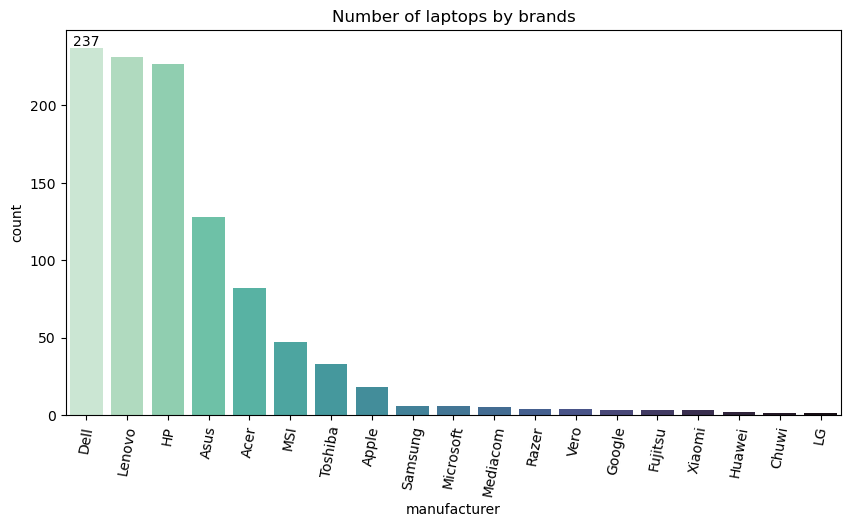

In [173]:
fig, ax  = plt.subplots(figsize = (10,5))
ax = sns.countplot(x = 'manufacturer', data = df1, palette='mako_r', order = df_train['manufacturer'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 80)
ax.bar_label(ax.containers[0])
plt.title('Number of laptops by brands')
plt.show()


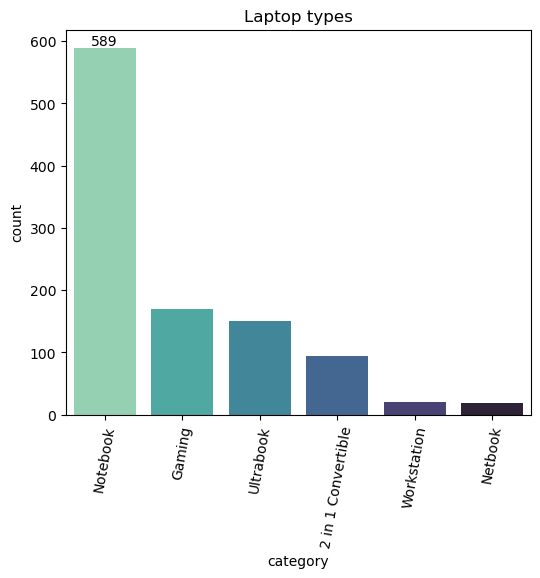

In [174]:
# Which type of Laptop is most frequent?
fig, ax  = plt.subplots(figsize = (6,5))
ax=sns.countplot(x = 'category', data = df_train, palette = 'mako_r', order = df_train['category'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 80);
ax.bar_label(ax.containers[0])
plt.title('Laptop types')
plt.show()

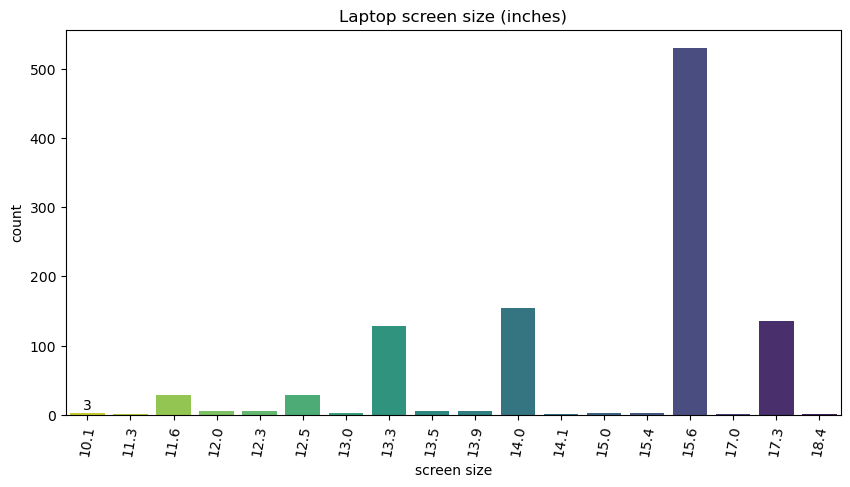

In [175]:
# Which Size is most popular?

fig, ax  = plt.subplots(figsize = (10,5))
ax=sns.countplot(x = 'screen size', data = df_train, palette = 'viridis_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 80);
ax.bar_label(ax.containers[0])
plt.title('Laptop screen size (inches)')
plt.show()

Majority of the laptops have 15.6 inches.

There are very few laptops with some "non conventional" sizes, which indeed appears in just few rows. For this reason, we will only keep laptops with the more conventional sizes.

In [176]:
inches_list = df_train['screen size'].value_counts().index[:6].tolist()
inches_list

[15.6, 14.0, 17.3, 13.3, 12.5, 11.6]

In [177]:
# We will keep laptop of these sizes 

df_clean = df_clean[df_clean['screen size'].isin(inches_list)]
df_test = df_test[df_test['screen size'].isin(inches_list)]

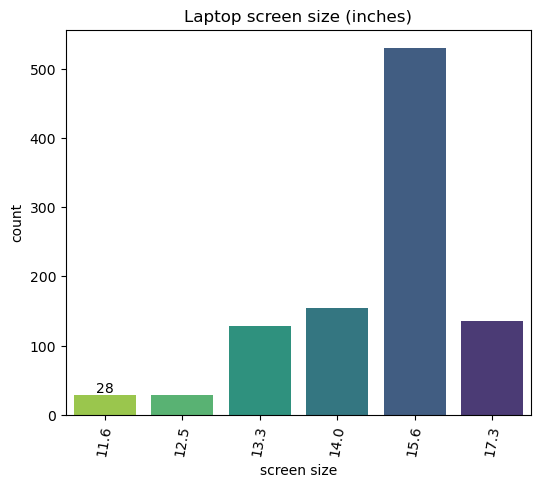

In [178]:
fig, ax  = plt.subplots(figsize = (6,5))
ax=sns.countplot(x = 'screen size', data = df_clean, palette = 'viridis_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 80);
ax.bar_label(ax.containers[0])
plt.title('Laptop screen size (inches)')
plt.show()

In [179]:
print('We removed {} outliers!'.format(len(df_train)-len(df_clean)))

We removed 36 outliers!


In [180]:
def num_plot(df, col, title, symb):
    fig, ax = plt.subplots(2, 1, sharex = True, figsize = (8,5),gridspec_kw = {"height_ratios": (.2, .8)})
    ax[0].set_title(title)
    sns.boxplot(x = col, data = df, ax = ax[0])
    ax[0].set(yticks = [])
    sns.histplot(x = col, data = df, ax = ax[1])
    ax[1].set_xlabel(col)
    plt.axvline(df[col].mean(), color = 'darkgreen', label = 'mean=' + str(np.round(df[col].mean(),1)) + symb)
    plt.axvline(df[col].median(), color = 'red', label = 'median='+ str(np.round(df[col].median(),1)) + symb)
    plt.axvline(df[col].mode()[0], color = 'purple', label = 'mode='+ str(df[col].mode()[0]) + symb)
    plt.legend(bbox_to_anchor = (1, 1.03), ncol = 1, fancybox = True, shadow = True, frameon = True)
    plt.tight_layout()
    plt.show()

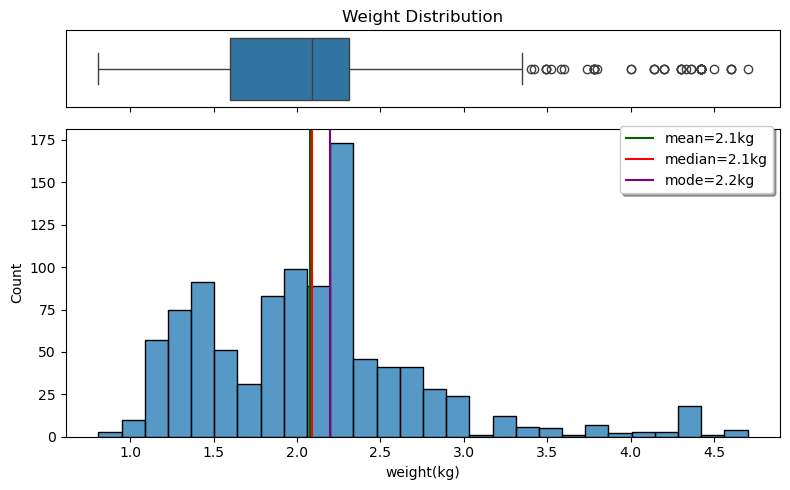

In [181]:
num_plot(df_clean, 'weight(kg)', 'Weight Distribution','kg')

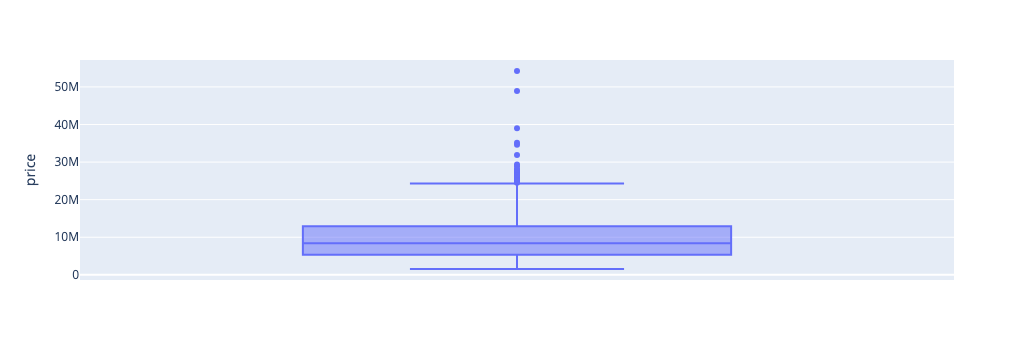

In [182]:
import plotly.express as px
fig = px.box(df_clean, y = 'price')
fig.show()

In [183]:
def remove_outliers(df, column):
    """
    Removes outliers from the dataframe based on IQR method.
    """
    Q1 = df[column].quantile(0.25)   # 25th percentile
    Q3 = df[column].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                    # Interquartile Range
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # Filter rows within the fences
    df_clean = df[(df[column] >= lower_fence) & (df[column] <= upper_fence)]
    return df_clean

# Apply to train and test datasets
df_train_clean = remove_outliers(df_clean, 'price')
df_test_clean = remove_outliers(df_test, 'price')

# Check sizes
print("Original Train Shape:", df_train.shape)
print("Cleaned Train Shape:", df_train_clean.shape)
print("Original Test Shape:", df_test.shape)
print("Cleaned Test Shape:", df_test_clean.shape)


Original Train Shape: (1041, 24)
Cleaned Train Shape: (975, 24)
Original Test Shape: (256, 24)
Cleaned Test Shape: (250, 24)


In [184]:
df_train_clean.columns

Index(['manufacturer', 'model name', 'category', 'screen size', 'ram(GB)',
       'operating system', 'operating system version', 'weight(kg)', 'price',
       'resolution', 'screen_type', 'touchscreen', 'cpu_freq(GHz)',
       'storage_1_gb', 'storage_1_type', 'storage_2_gb', 'storage_2_type',
       'cpu_brand', 'gpu_brand', 'cpu_series', 'cpu_generation', 'cpu_type',
       'gpu_type', 'gpu_category'],
      dtype='object')

In [185]:
df_train_clean.head()

,manufacturer,model name,category,screen size,ram(GB),operating system,operating system version,weight(kg),price,resolution,...,storage_1_type,storage_2_gb,storage_2_type,cpu_brand,gpu_brand,cpu_series,cpu_generation,cpu_type,gpu_type,gpu_category
0,Toshiba,Satellite Pro,Notebook,15.6,8.0,Windows,10,2.20,9274356.0,1920x1080,...,SSD,0.0,NaN,Intel,Nvidia,i7,6.0,Standard,GeForce 930M,Dedicated
1,Dell,XPS 15,Notebook,15.6,16.0,Windows,10,2.06,21331908.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,GeForce GTX 1050,Dedicated
2,Dell,Precision M5520,Workstation,15.6,8.0,Windows,10,1.78,24115104.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,Quadro M1200,Integrated
3,Acer,Aspire 3,Notebook,15.6,4.0,Windows,10,2.10,2961036.0,1366x768,...,HDD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron,HD Graphics 500,Integrated
4,Apple,MacBook Pro,Ultrabook,13.3,8.0,macOS,NaN,1.37,12617748.0,2560x1600,...,SSD,0.0,NaN,Intel,Intel,i5,NaN,Standard,Iris Graphics 540,Integrated


In [186]:
df_train["gpu_type"].value_counts()

gpu_type
HD Graphics 620     233
HD Graphics 520     140
UHD Graphics 620     55
GeForce GTX 1050     49
GeForce GTX 1060     40
                   ... 
GeForce GTX1080       1
GeForce 960M          1
Radeon Pro 455        1
Radeon R7 M365X       1
Mali T860 MP4         1
Name: count, Length: 99, dtype: int64

## Price VS CPU brand by GPU brand

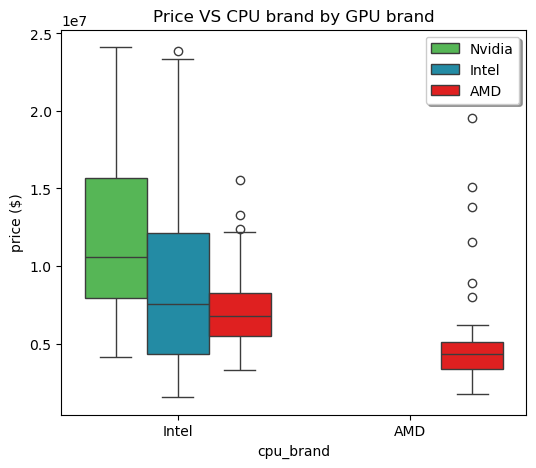

In [187]:
cpu_palette = {'Intel':'#0d98ba', 'AMD':'#FF0000', 'Nvidia':'#46C646'}
fig, ax = plt.subplots(figsize = (6,5))
sns.boxplot(x = 'cpu_brand', y = 'price', data = df_train_clean, hue = 'gpu_brand', palette = cpu_palette)
ax.set_title('Price vs CPU brand by GPU brand')
plt.ylabel('price ($)')
plt.legend(loc = 'upper right', ncol=1, fancybox = True, shadow = True, frameon = True)
plt.title('Price VS CPU brand by GPU brand')
plt.show()

### Insights from this plot:

Laptops with Intel CPUs are more expensive. 
Laptops with an AMD CPUs also have and AMD GPUs is least expensive
Laptops with Nvidia GPUs are more expensive.

In [188]:
df_train_clean['manufacturer'].value_counts()

manufacturer
Dell        224
HP          222
Lenovo      217
Asus        123
Acer         82
MSI          45
Toshiba      32
Apple        10
Mediacom      5
Vero          4
Fujitsu       3
Samsung       3
Xiaomi        3
Razer         1
LG            1
Name: count, dtype: int64

In particular, there are companies with less than 10 laptops in the dataset, which is a very low number from which we can extract statistical results.
For this reason, we will consider only laptops with at least 20 laptops in the dataset.

In [189]:
company_list = df_train_clean['manufacturer'].value_counts().index[:8].tolist()
company_list

['Dell', 'HP', 'Lenovo', 'Asus', 'Acer', 'MSI', 'Toshiba', 'Apple']

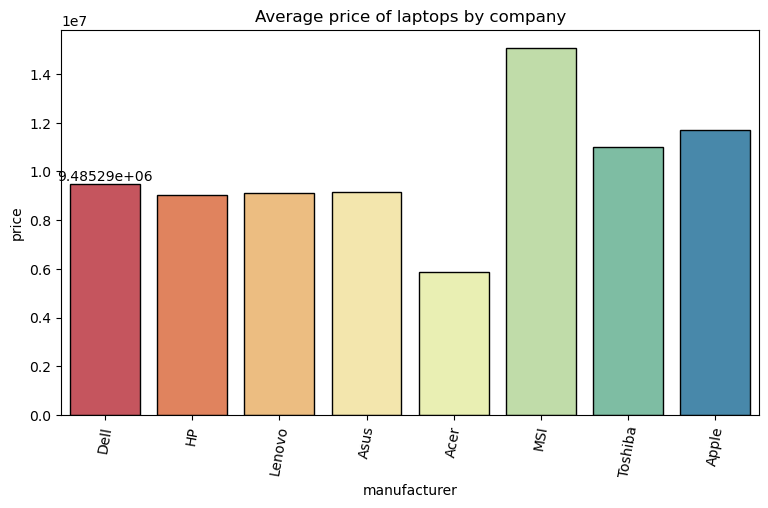

In [190]:
plt.figure(figsize = (9,5))
ax=sns.barplot(x = 'manufacturer', y = 'price', data = df_train_clean[df_train_clean['manufacturer'].isin(company_list)],
                order = company_list, 
                palette = 'Spectral', 
                ci = False,
                edgecolor = "black")
plt.xticks(rotation = 80);
ax.bar_label(ax.containers[0])
plt.title('Average price of laptops by company')
plt.show()

MSI laptops are on average the most expensive.
Apple laptops are the second most expensive laptops and Toshiba's are 3rd.
Acer are the cheapest, with an average price of 626$
Laptops from Dell, Lenovo, HP and Asus have, on average.

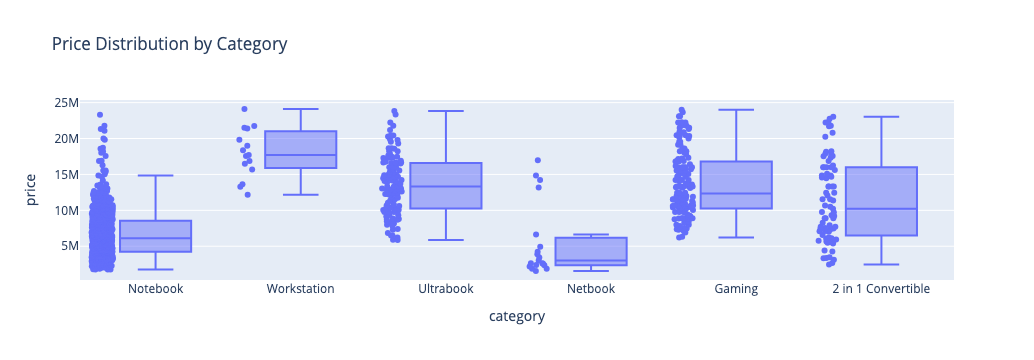

In [191]:
fig = px.box(df_train_clean, x='category', y='price', points='all', title='Price Distribution by Category')
fig.show()

In [192]:
df1 = df_train_clean.copy()

## Categorical features encoding
The categorical columns ('company','product','typename','cpu','gpu','opsys','resolution','screentype','resolution','memory_1_type','memory_2_type','gpu_brand','cpu_brand') will be now encoded.
An encoding by one hot encoding would be preferrable in this case since there is not a order/hierarchy among the different categories for each variable, but this would lead to a very high number of columns (around 900), which is close to the number of total rows (1000).
So, if we had more data a OHE encoding would be preferrable, but in case a Label Encoding will be performed to keep the number of features lower.

In [193]:
cat_cols=[
    'manufacturer', 
    'model name', 
    'category', 
    'operating system', 
    'operating system version',
    'resolution',
    'screen_type',
    'touchscreen',
    'storage_1_type',
    'storage_2_type',
    'cpu_brand',
    'gpu_brand',
    'cpu_series',
    'cpu_type',
    'gpu_type',
    'gpu_category'
]

In [194]:
df1.head()

,manufacturer,model name,category,screen size,ram(GB),operating system,operating system version,weight(kg),price,resolution,...,storage_1_type,storage_2_gb,storage_2_type,cpu_brand,gpu_brand,cpu_series,cpu_generation,cpu_type,gpu_type,gpu_category
0,Toshiba,Satellite Pro,Notebook,15.6,8.0,Windows,10,2.20,9274356.0,1920x1080,...,SSD,0.0,NaN,Intel,Nvidia,i7,6.0,Standard,GeForce 930M,Dedicated
1,Dell,XPS 15,Notebook,15.6,16.0,Windows,10,2.06,21331908.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,GeForce GTX 1050,Dedicated
2,Dell,Precision M5520,Workstation,15.6,8.0,Windows,10,1.78,24115104.0,3840x2160,...,SSD,0.0,NaN,Intel,Nvidia,i7,7.0,Standard,Quadro M1200,Integrated
3,Acer,Aspire 3,Notebook,15.6,4.0,Windows,10,2.10,2961036.0,1366x768,...,HDD,0.0,NaN,Intel,Intel,Celeron,NaN,Celeron,HD Graphics 500,Integrated
4,Apple,MacBook Pro,Ultrabook,13.3,8.0,macOS,NaN,1.37,12617748.0,2560x1600,...,SSD,0.0,NaN,Intel,Intel,i5,NaN,Standard,Iris Graphics 540,Integrated


In [195]:
df1.columns

Index(['manufacturer', 'model name', 'category', 'screen size', 'ram(GB)',
       'operating system', 'operating system version', 'weight(kg)', 'price',
       'resolution', 'screen_type', 'touchscreen', 'cpu_freq(GHz)',
       'storage_1_gb', 'storage_1_type', 'storage_2_gb', 'storage_2_type',
       'cpu_brand', 'gpu_brand', 'cpu_series', 'cpu_generation', 'cpu_type',
       'gpu_type', 'gpu_category'],
      dtype='object')

In [196]:
from scipy.stats import pearsonr
import numpy as np

# List of numerical features
numerical_features = [
    'screen size',       # continuous (after cleaning quotes)
    'ram(GB)',           # discrete numeric
    'weight(kg)',        # continuous             
    'cpu_freq(GHz)',     # continuous
    'storage_1_gb',      # discrete numeric
    'storage_2_gb',      # discrete numeric
    'cpu_generation'     # discrete numeric
]


# Loop through numerical features safely
for feature in numerical_features:
    # Filter numeric data and drop NaNs
    temp_df = df1[[feature, 'price']].apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check for infinities or non-numeric issues
    if not np.isfinite(temp_df[feature]).all() or not np.isfinite(temp_df['price']).all():
        print(f"⚠️ Skipping {feature} due to non-finite values")
        continue

    # Compute Pearson correlation
    pearson_coef, p_value = pearsonr(temp_df[feature], temp_df['price'])
    print(f"🔹 Feature: {feature}")
    print(f"➡ Pearson Correlation Coefficient: {pearson_coef:.4f}")
    print(f"➡ P-value: {p_value:.4e}\n")

🔹 Feature: screen size
➡ Pearson Correlation Coefficient: -0.0223
➡ P-value: 4.8625e-01

🔹 Feature: ram(GB)
➡ Pearson Correlation Coefficient: 0.7060
➡ P-value: 5.5388e-148

🔹 Feature: weight(kg)
➡ Pearson Correlation Coefficient: 0.0780
➡ P-value: 1.4901e-02

🔹 Feature: cpu_freq(GHz)
➡ Pearson Correlation Coefficient: 0.4613
➡ P-value: 1.5561e-52

🔹 Feature: storage_1_gb
➡ Pearson Correlation Coefficient: -0.2018
➡ P-value: 2.0211e-10

🔹 Feature: storage_2_gb
➡ Pearson Correlation Coefficient: 0.3301
➡ P-value: 3.1831e-26

🔹 Feature: cpu_generation
➡ Pearson Correlation Coefficient: -0.0076
➡ P-value: 8.2788e-01



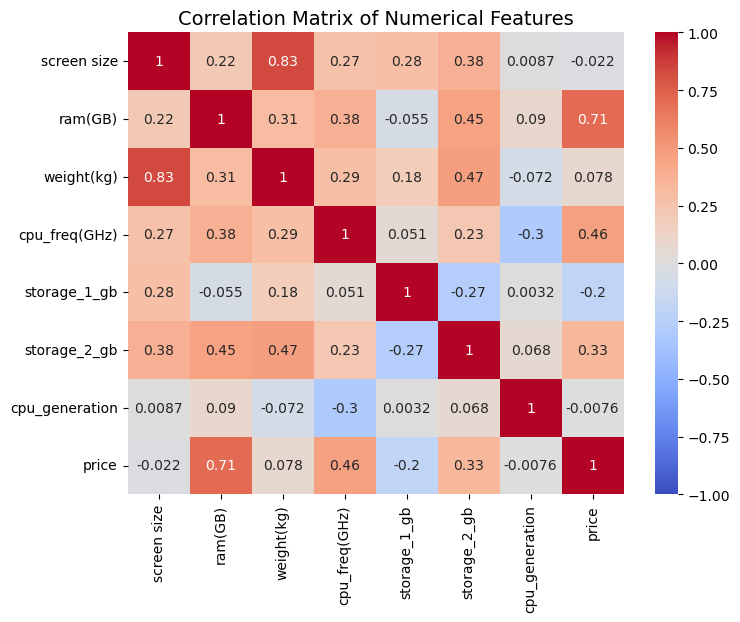

In [197]:
import seaborn as sns

# Select numerical features
numerical_features = ['screen size', 'ram(GB)', 'weight(kg)', 
                      'cpu_freq(GHz)', 'storage_1_gb', 'storage_2_gb', 'cpu_generation', 'price']

# Compute correlation matrix
corr_matrix = df1[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

Average Price per Category in 'manufacturer':


manufacturer
Razer       2.311031e+07
LG          1.866431e+07
MSI         1.505132e+07
Apple       1.169599e+07
Toshiba     1.098495e+07
Xiaomi      1.066699e+07
Samsung     1.012799e+07
Dell        9.485293e+06
Asus        9.176253e+06
Lenovo      9.112224e+06
HP          9.027429e+06
Fujitsu     6.482268e+06
Acer        5.876137e+06
Mediacom    2.555561e+06
Vero        1.933343e+06
Name: price, dtype: float64

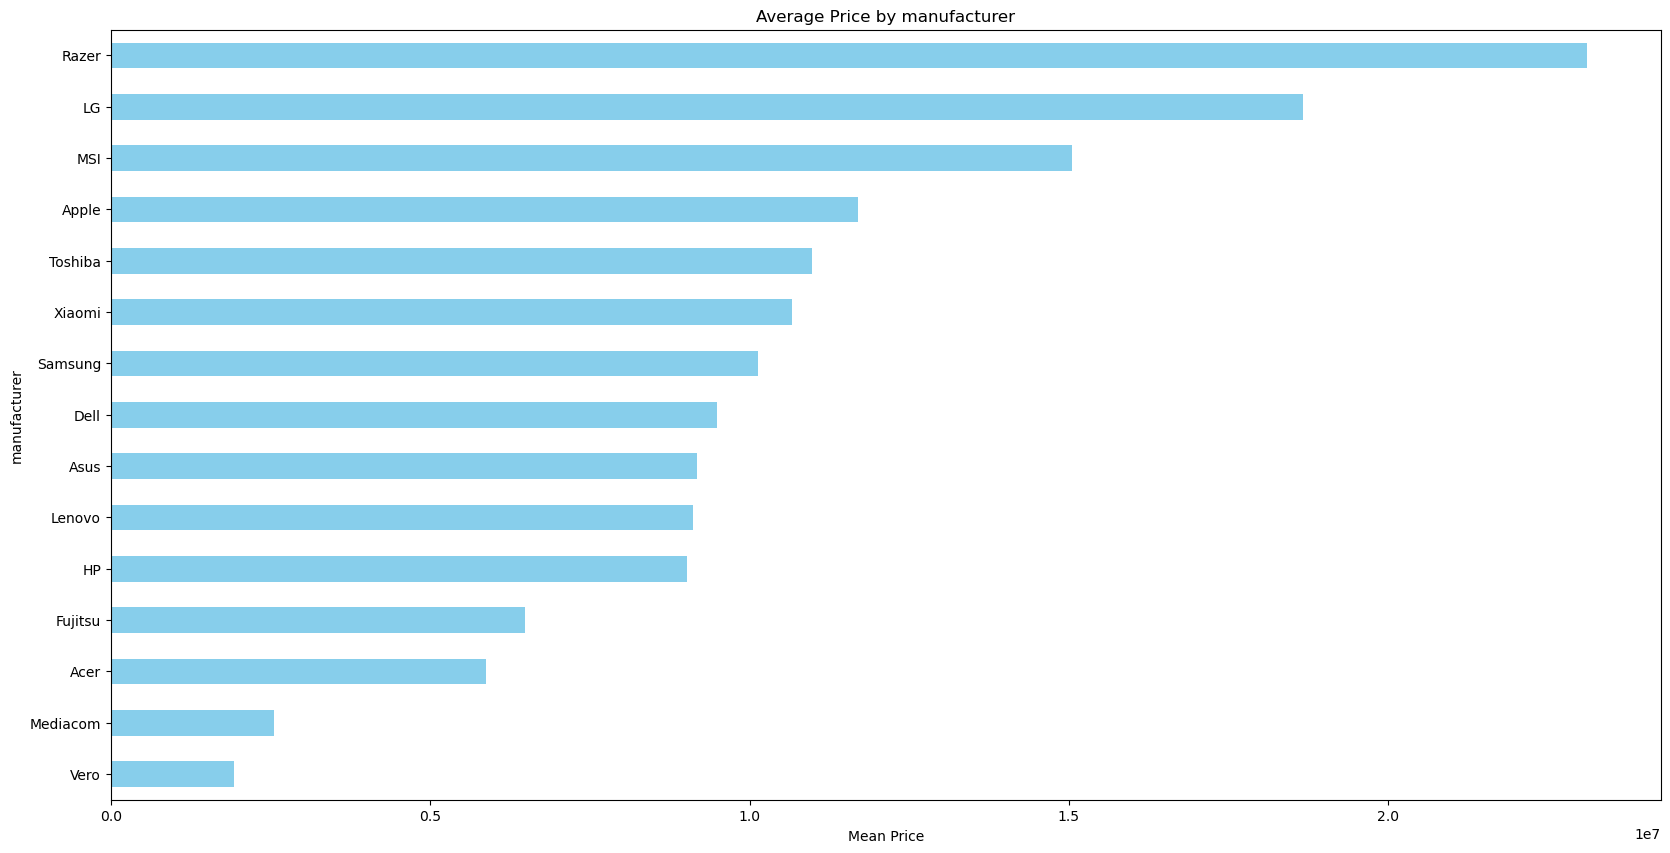

Average Price per Category in 'model name':


model name
IdeaPad Y910-17ISK                      23679396.0
Blade Pro                               23110308.0
Precision M5520                         22763520.0
GT72VR Dominator                        22221108.0
GT73EVR 7RE                             22221108.0
                                           ...    
K146 (N3350/4GB/32GB/W10)                1804186.8
Chromebook C910-C2ST                     1769508.0
E402WA-GA010T (E2-6110/2GB/32GB/W10)     1769508.0
V131 (X5-Z8350/4GB/32GB/FHD/W10)         1742832.0
C740-C9QX (3205U/2GB/32GB/Chrome         1547208.0
Name: price, Length: 502, dtype: float64

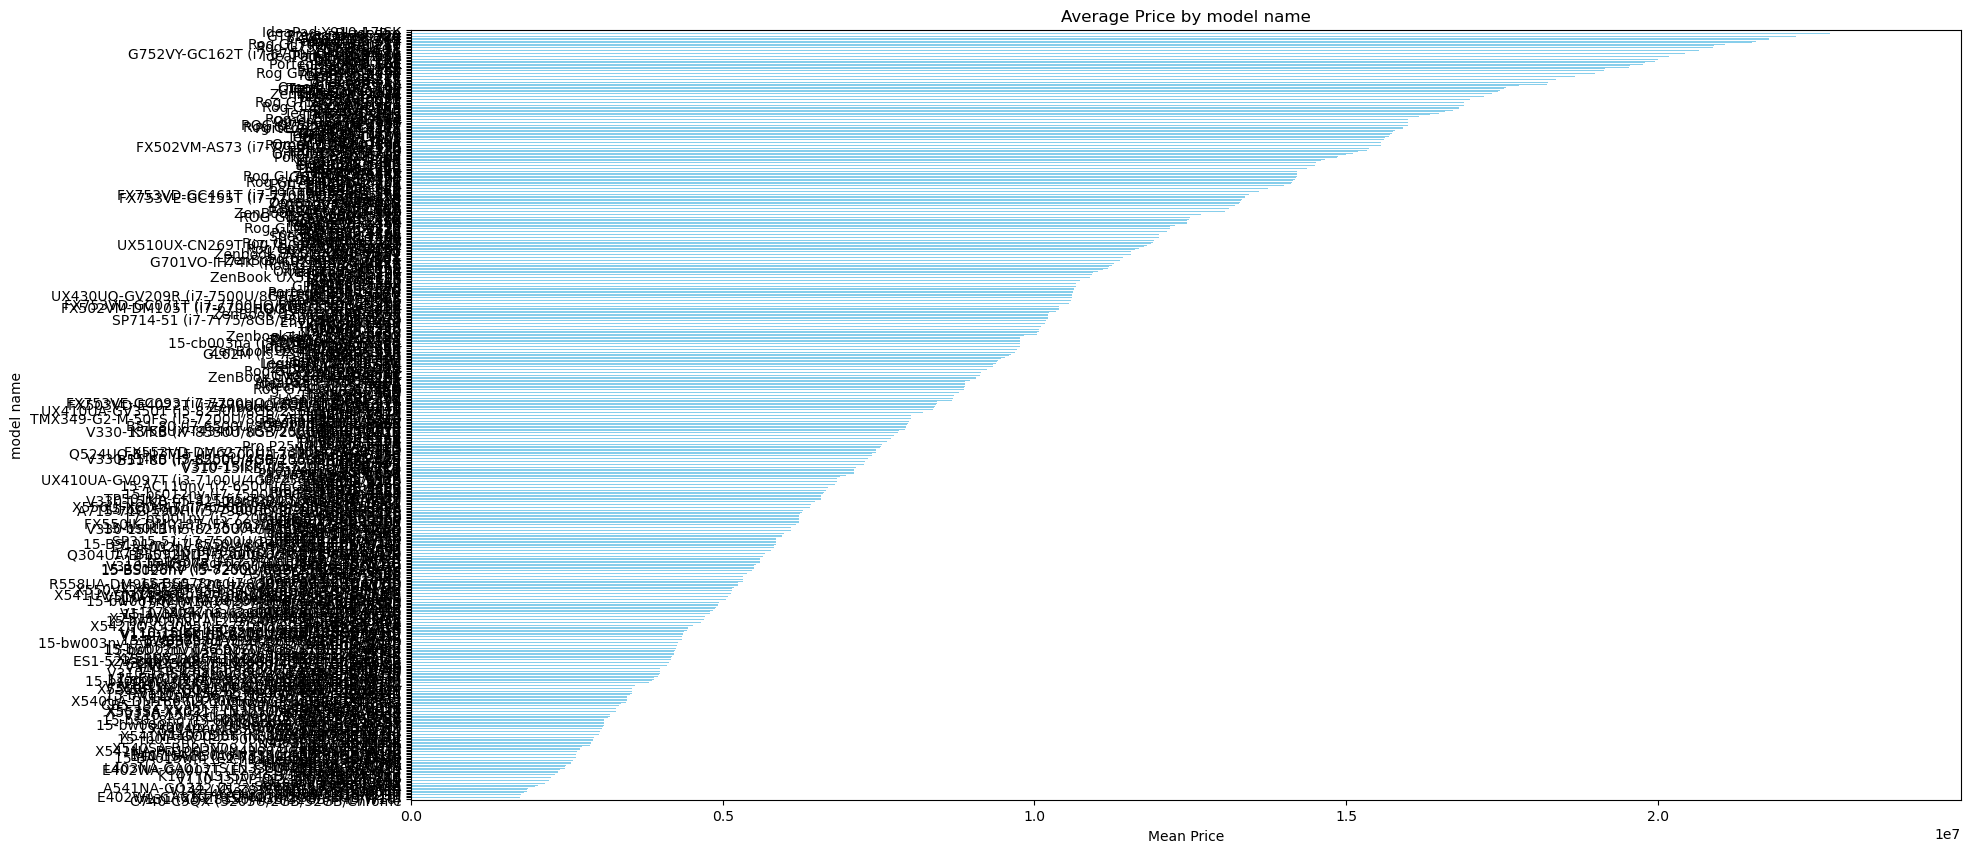

Average Price per Category in 'category':


category
Workstation           1.795941e+07
Ultrabook             1.359657e+07
Gaming                1.358360e+07
2 in 1 Convertible    1.128849e+07
Notebook              6.792439e+06
Netbook               5.542009e+06
Name: price, dtype: float64

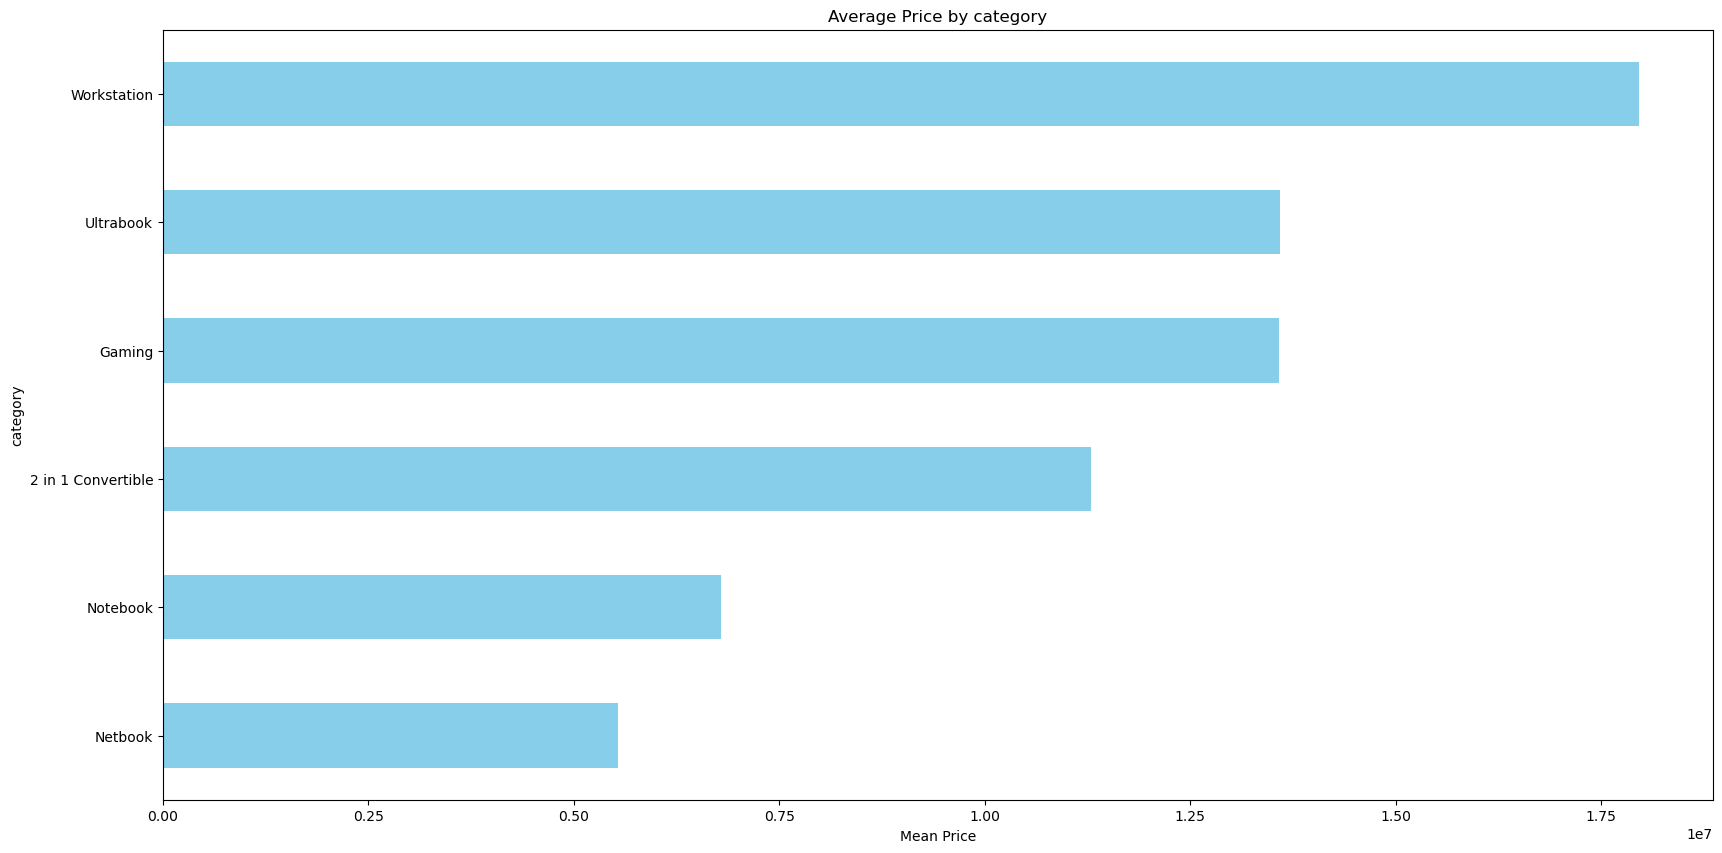

Average Price per Category in 'operating system':


operating system
macOS        1.282656e+07
Windows      9.806571e+06
Mac OS       9.057984e+06
Linux        5.365105e+06
No OS        5.248797e+06
Chrome OS    3.304922e+06
Name: price, dtype: float64

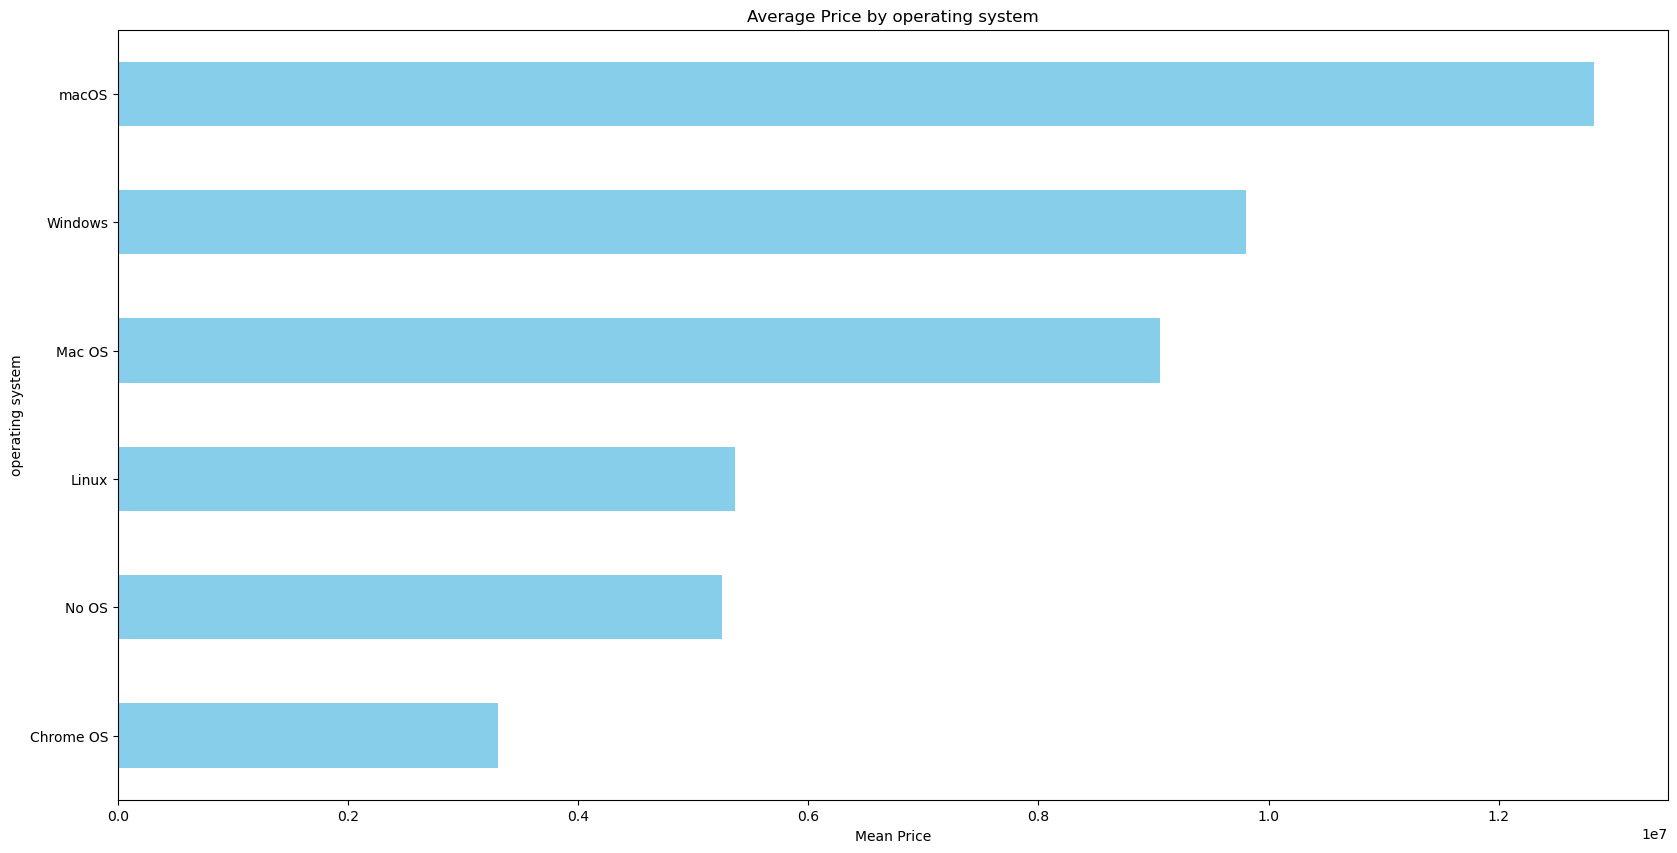

Average Price per Category in 'operating system version':


operating system version
7       1.368494e+07
10      9.671116e+06
X       9.057984e+06
10 S    2.747584e+06
Name: price, dtype: float64

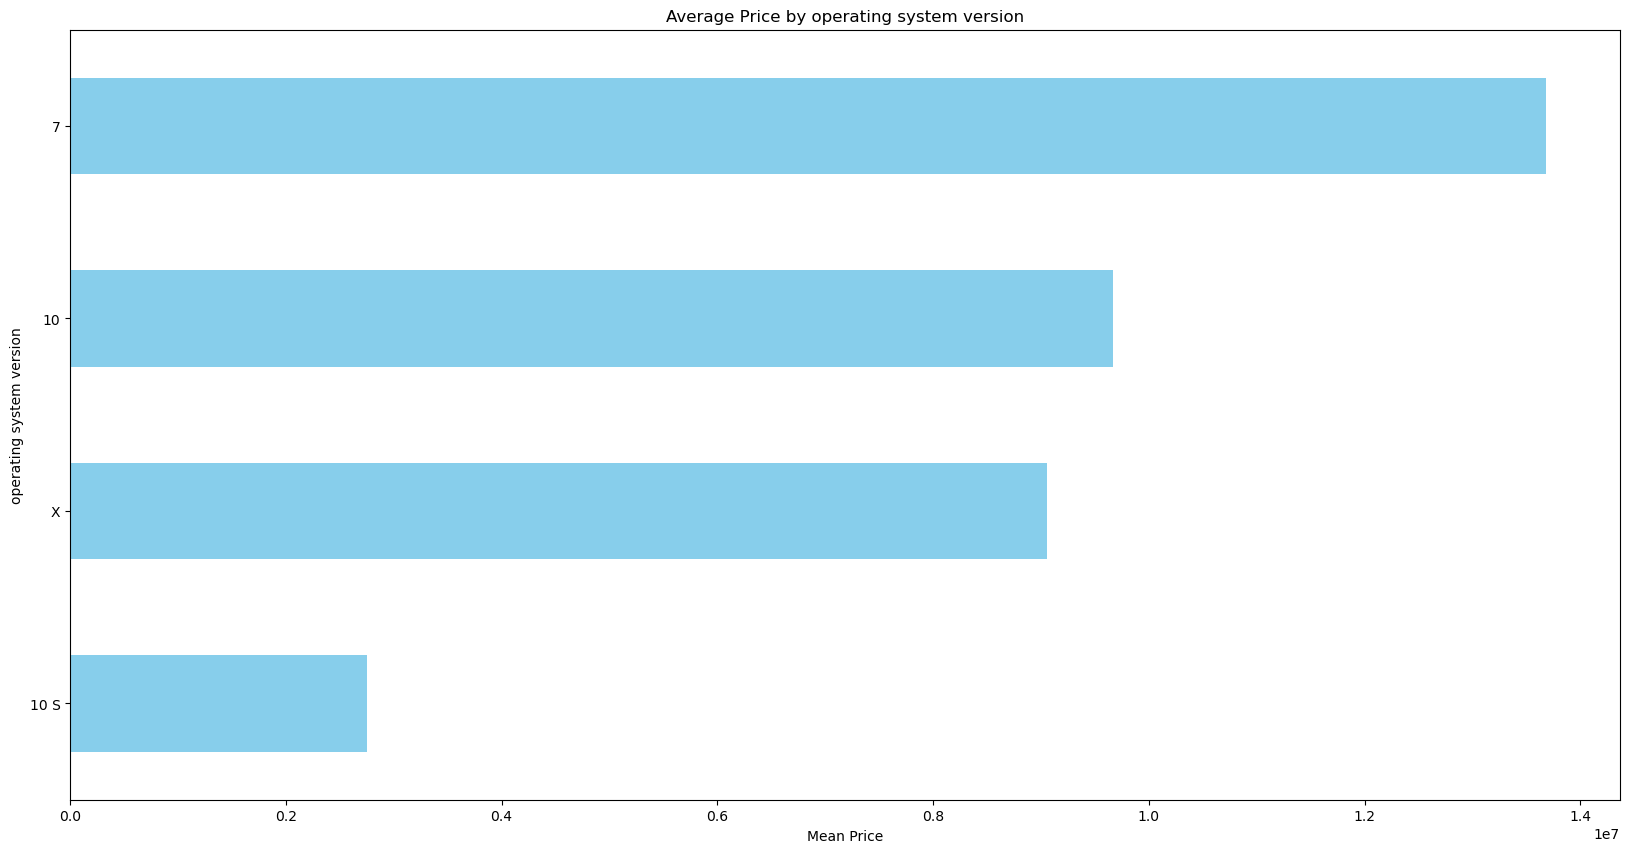

Average Price per Category in 'resolution':


resolution
2560x1440    1.914579e+07
3840x2160    1.745180e+07
2560x1600    1.429787e+07
3200x1800    1.401384e+07
1920x1080    1.029784e+07
1440x900     9.235765e+06
1600x900     5.569526e+06
1366x768     4.823517e+06
1920x1200    2.356380e+06
Name: price, dtype: float64

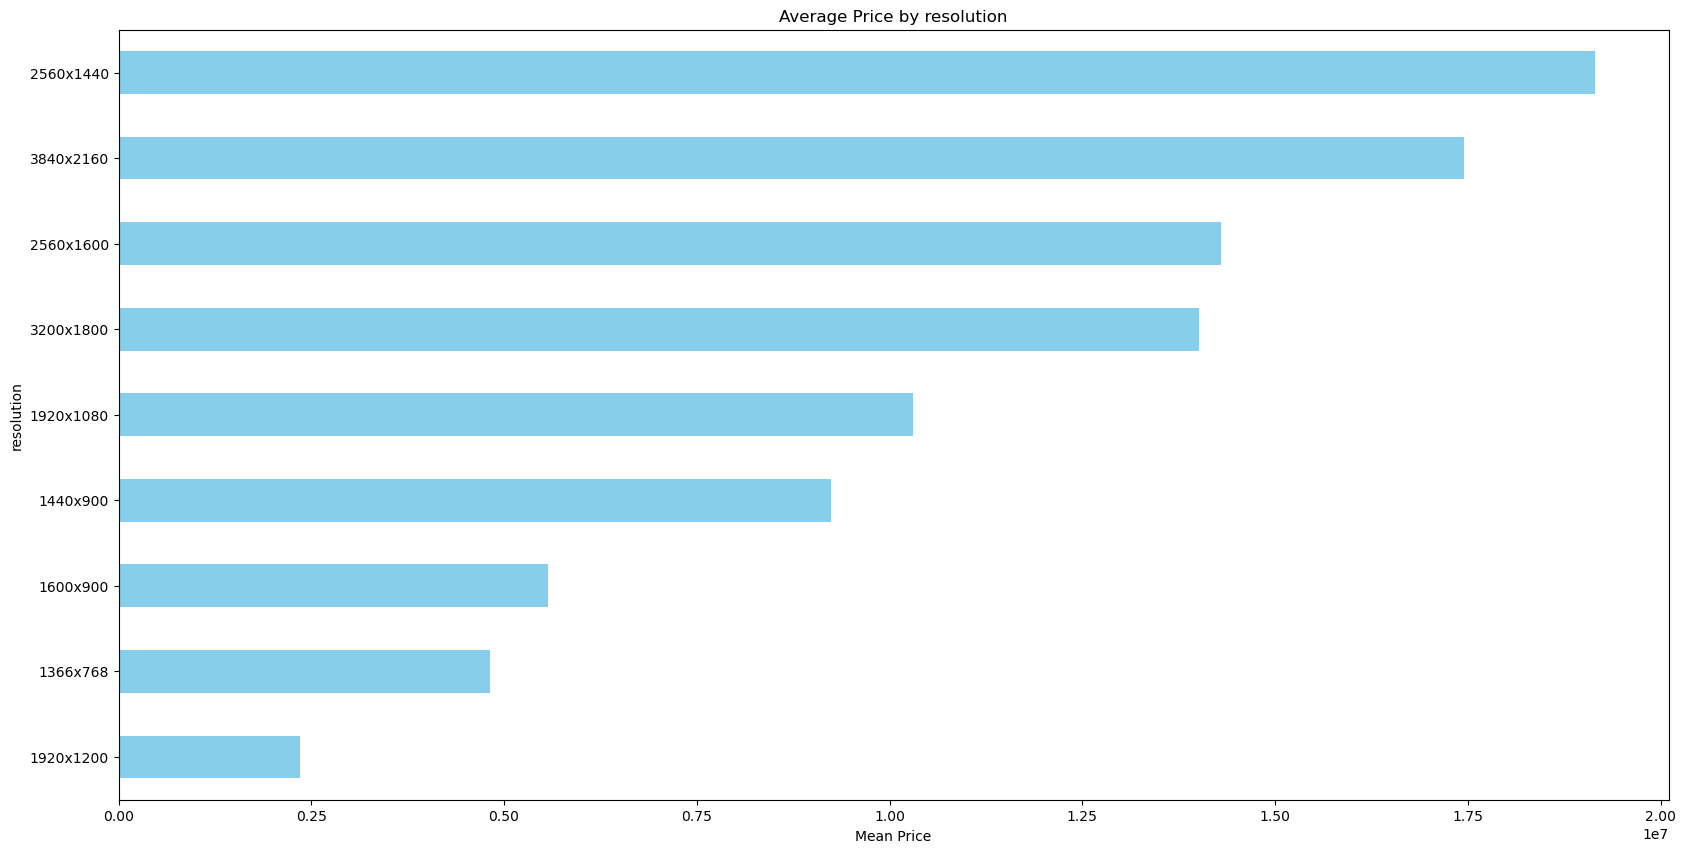

Average Price per Category in 'screen_type':


screen_type
IPSPanelRetinaDisplay    1.429787e+07
IPSPanel                 1.137942e+07
Name: price, dtype: float64

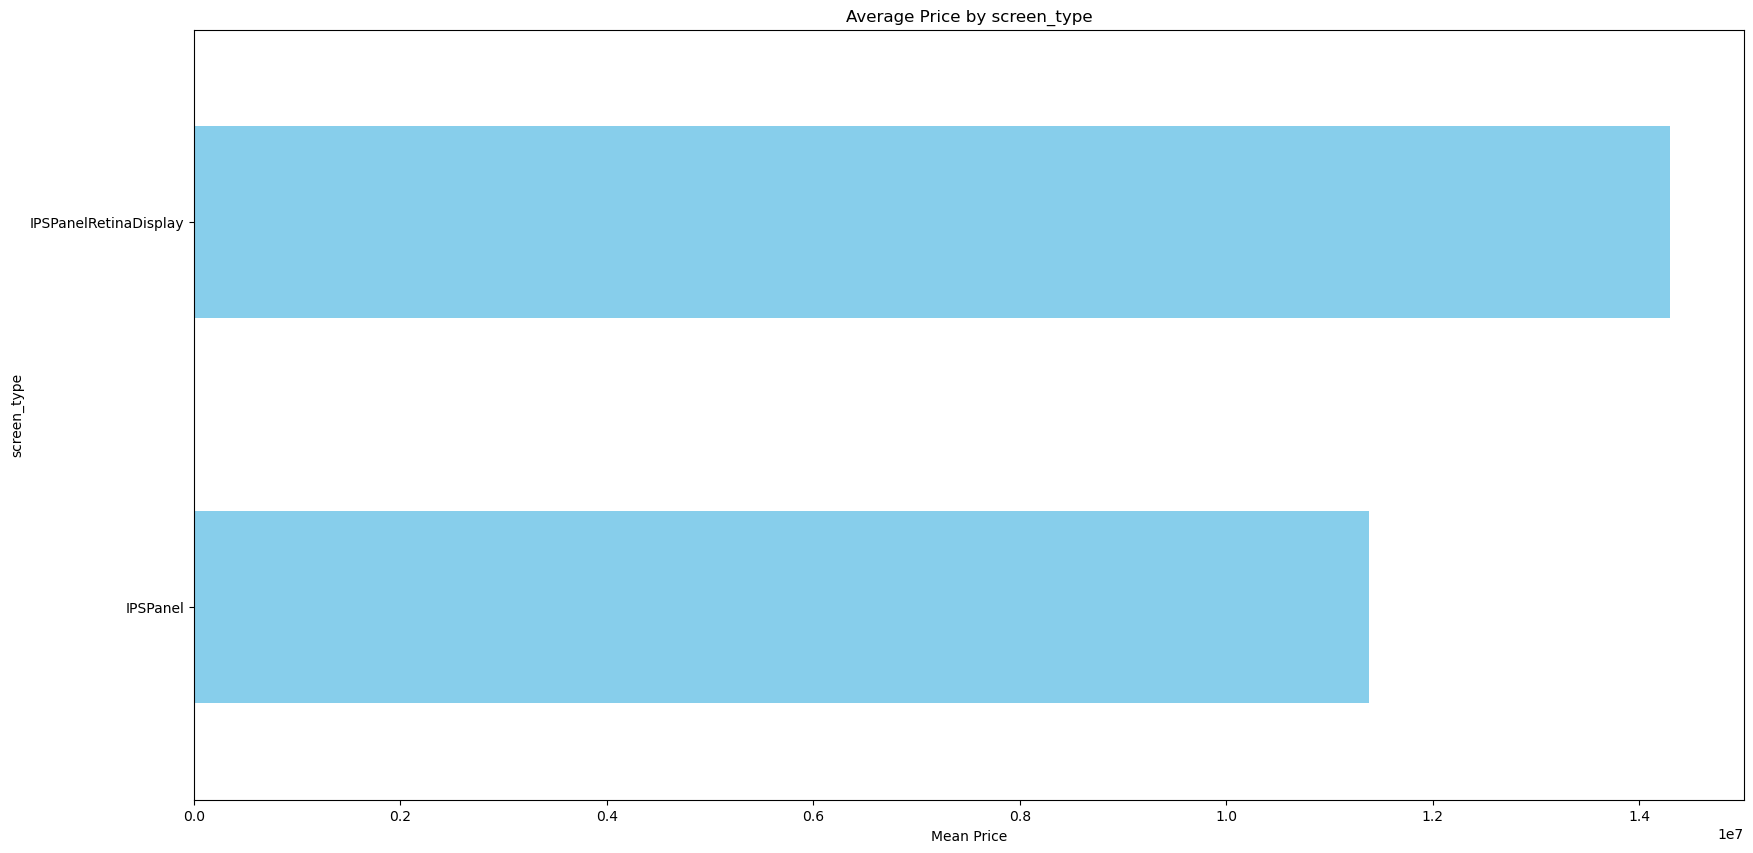

Average Price per Category in 'touchscreen':


touchscreen
1.0    1.197946e+07
0.0    8.852678e+06
Name: price, dtype: float64

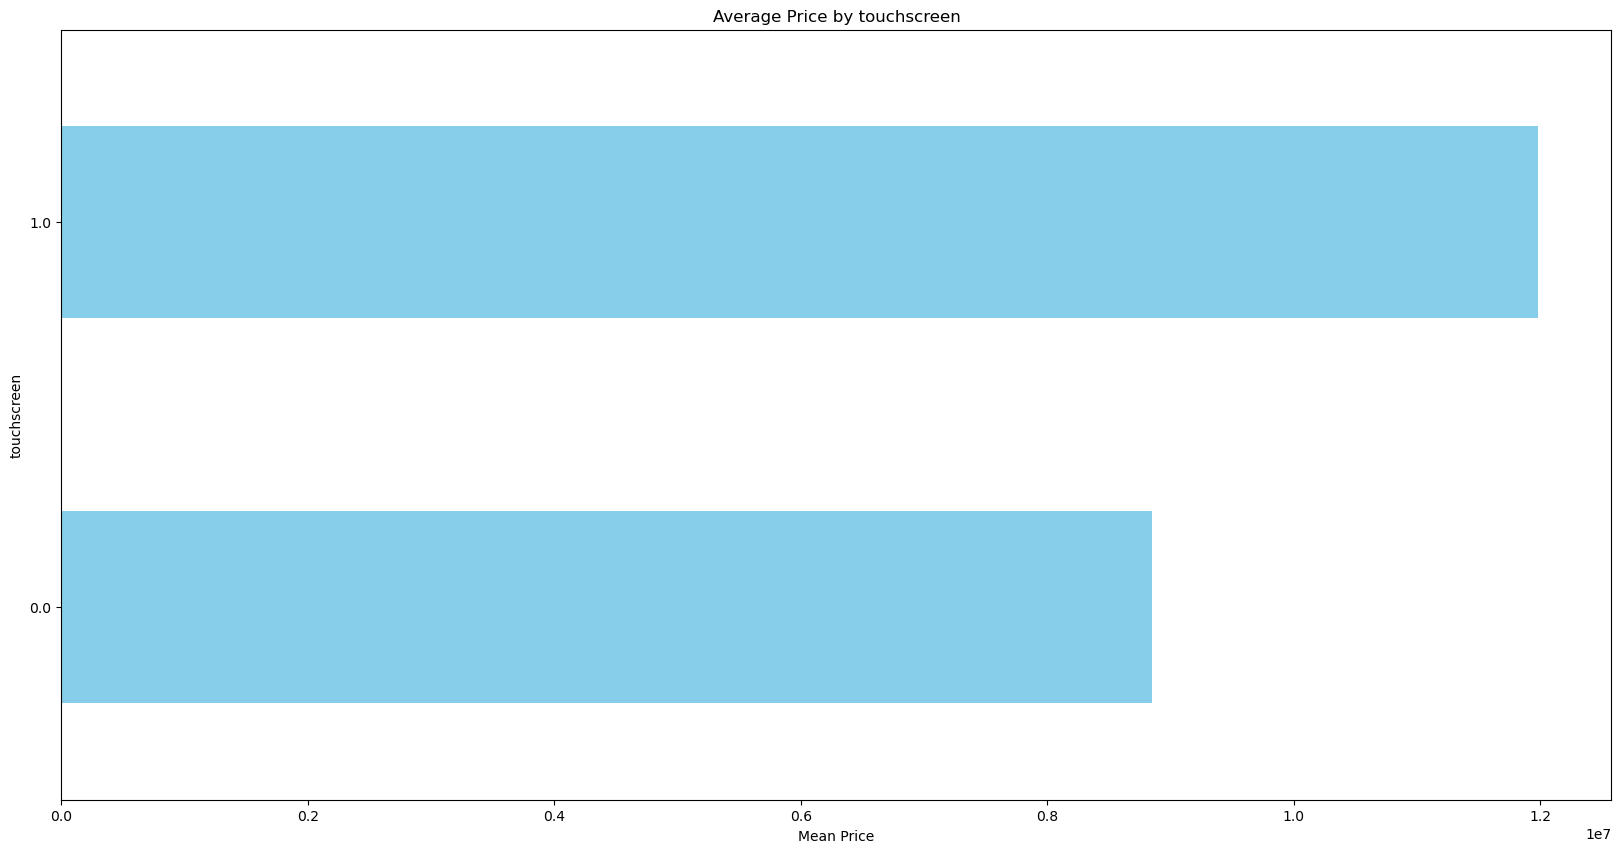

Average Price per Category in 'storage_1_type':


storage_1_type
SSD             1.145026e+07
Hybrid          7.021312e+06
HDD             5.783836e+06
FlashStorage    4.314260e+06
Name: price, dtype: float64

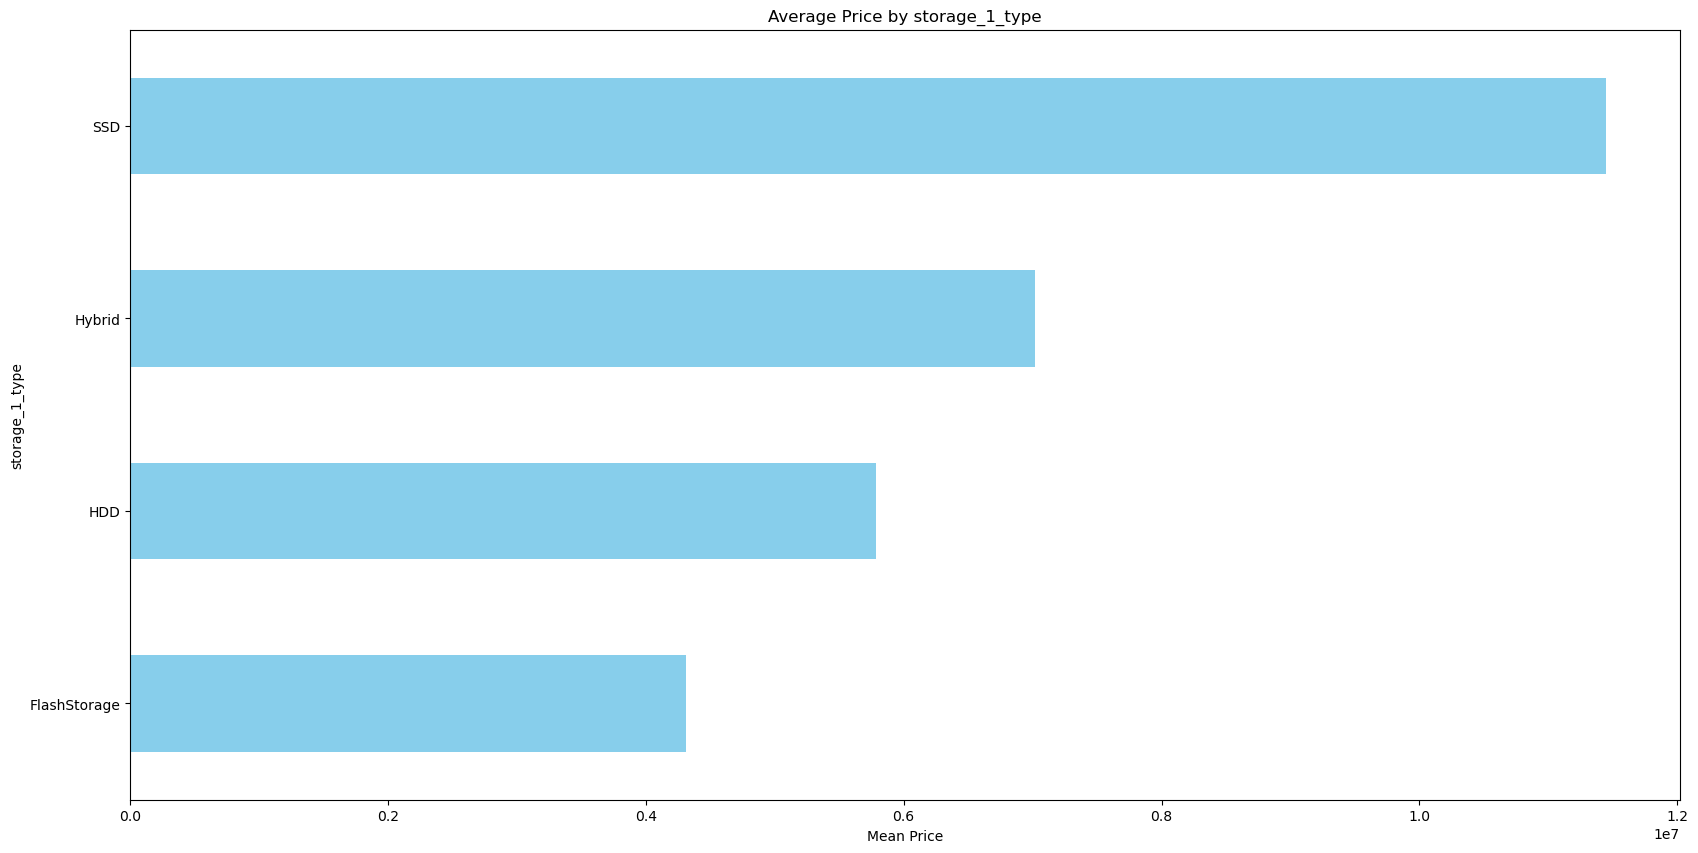

Average Price per Category in 'storage_2_type':


storage_2_type
HDD    1.332395e+07
SSD    1.299999e+07
Name: price, dtype: float64

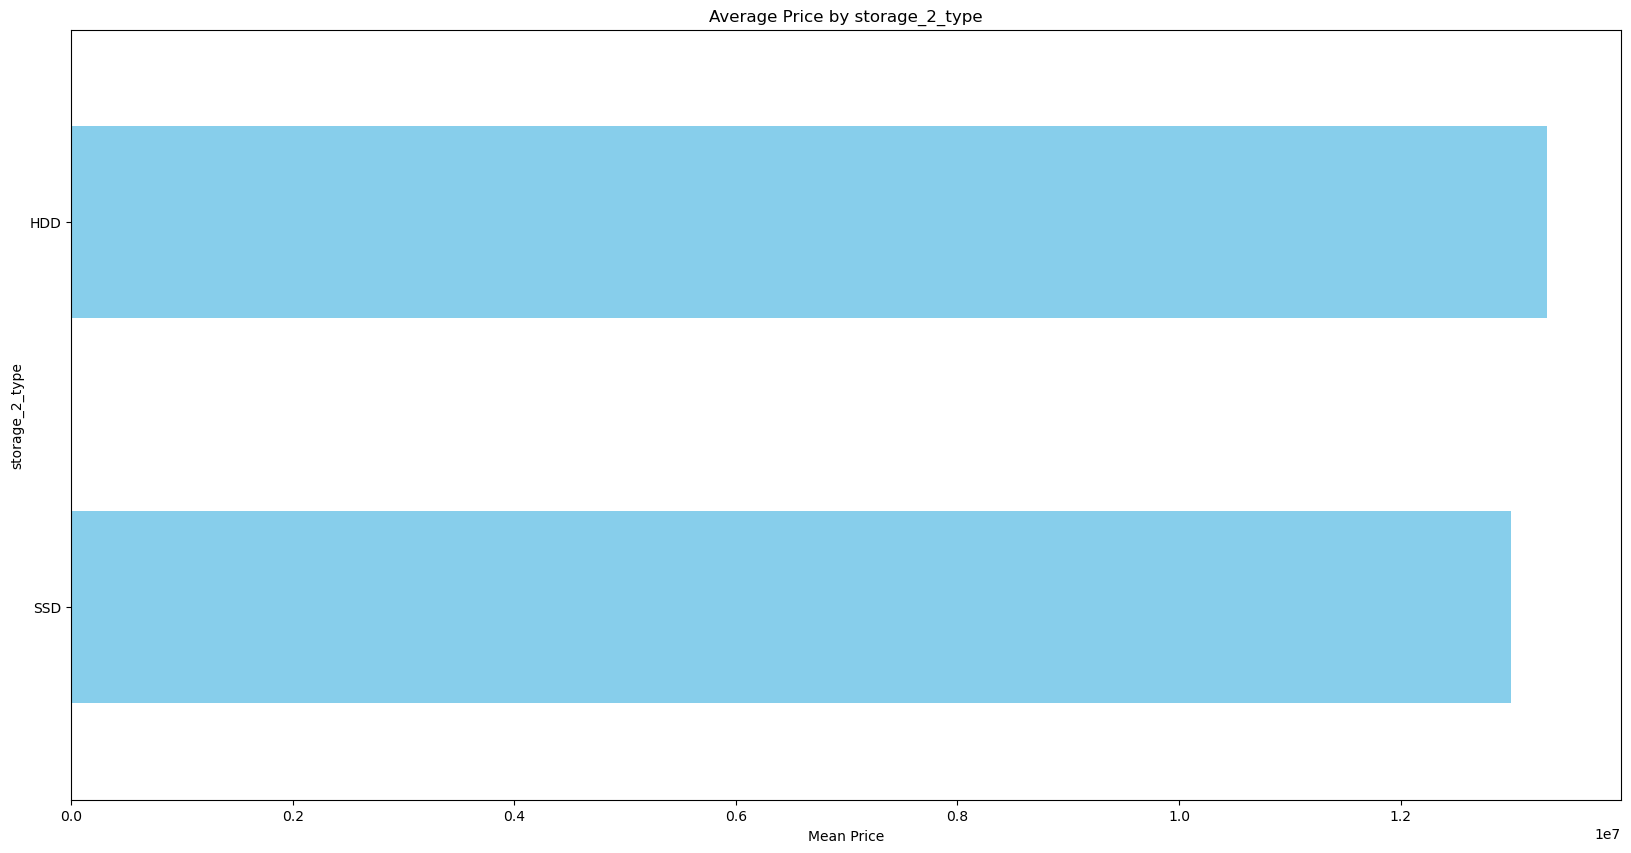

Average Price per Category in 'cpu_brand':


cpu_brand
Intel    9.462535e+06
AMD      5.074613e+06
Name: price, dtype: float64

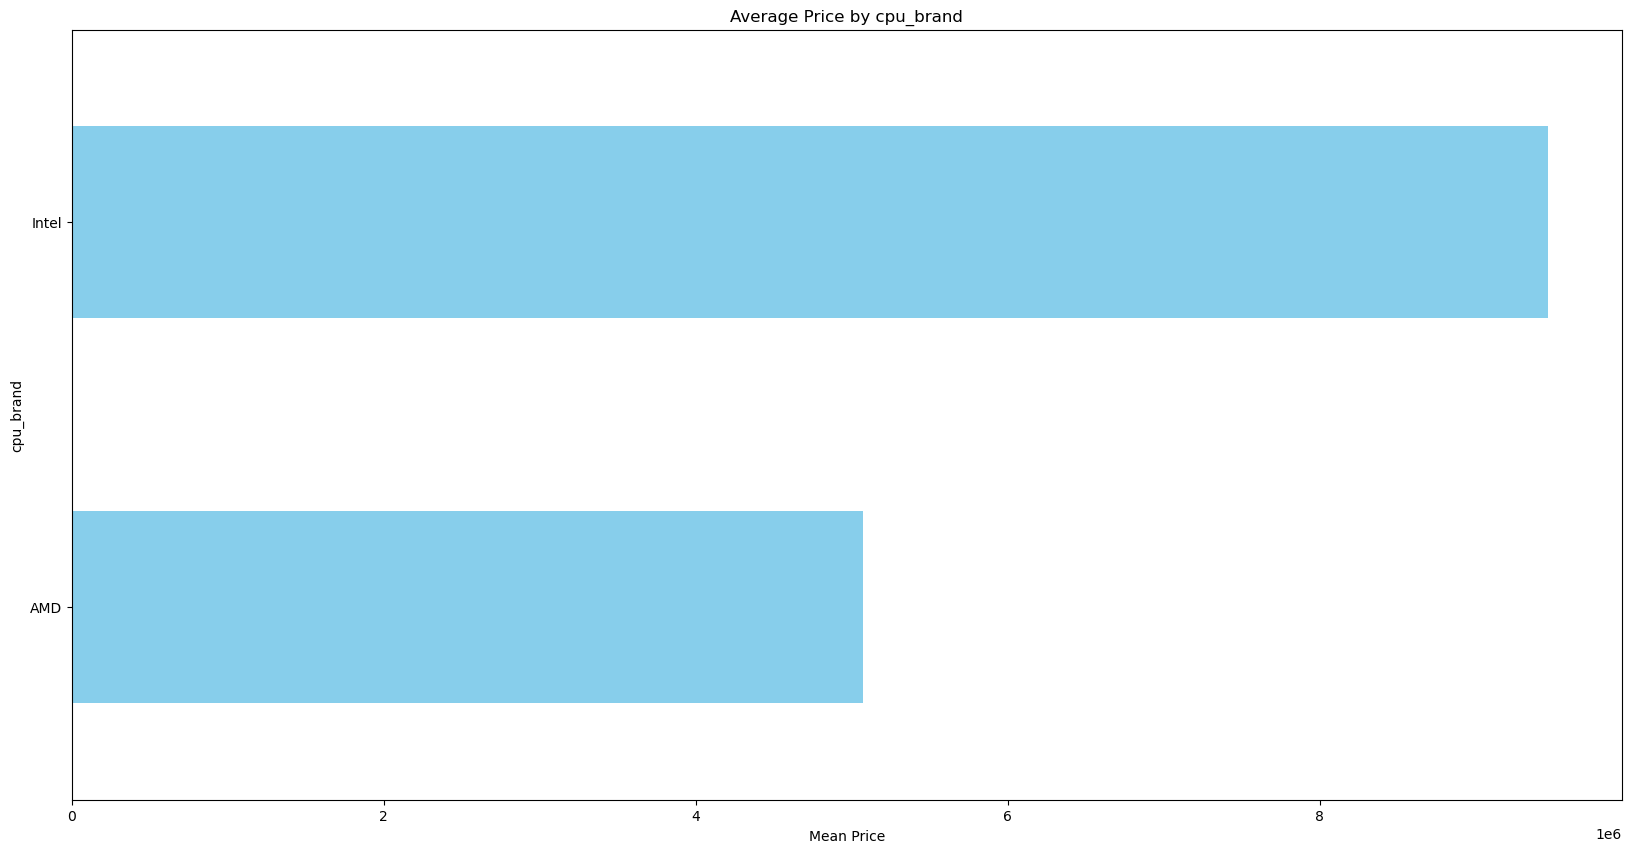

Average Price per Category in 'gpu_brand':


gpu_brand
Nvidia    1.176059e+07
Intel     8.639845e+06
AMD       6.488410e+06
Name: price, dtype: float64

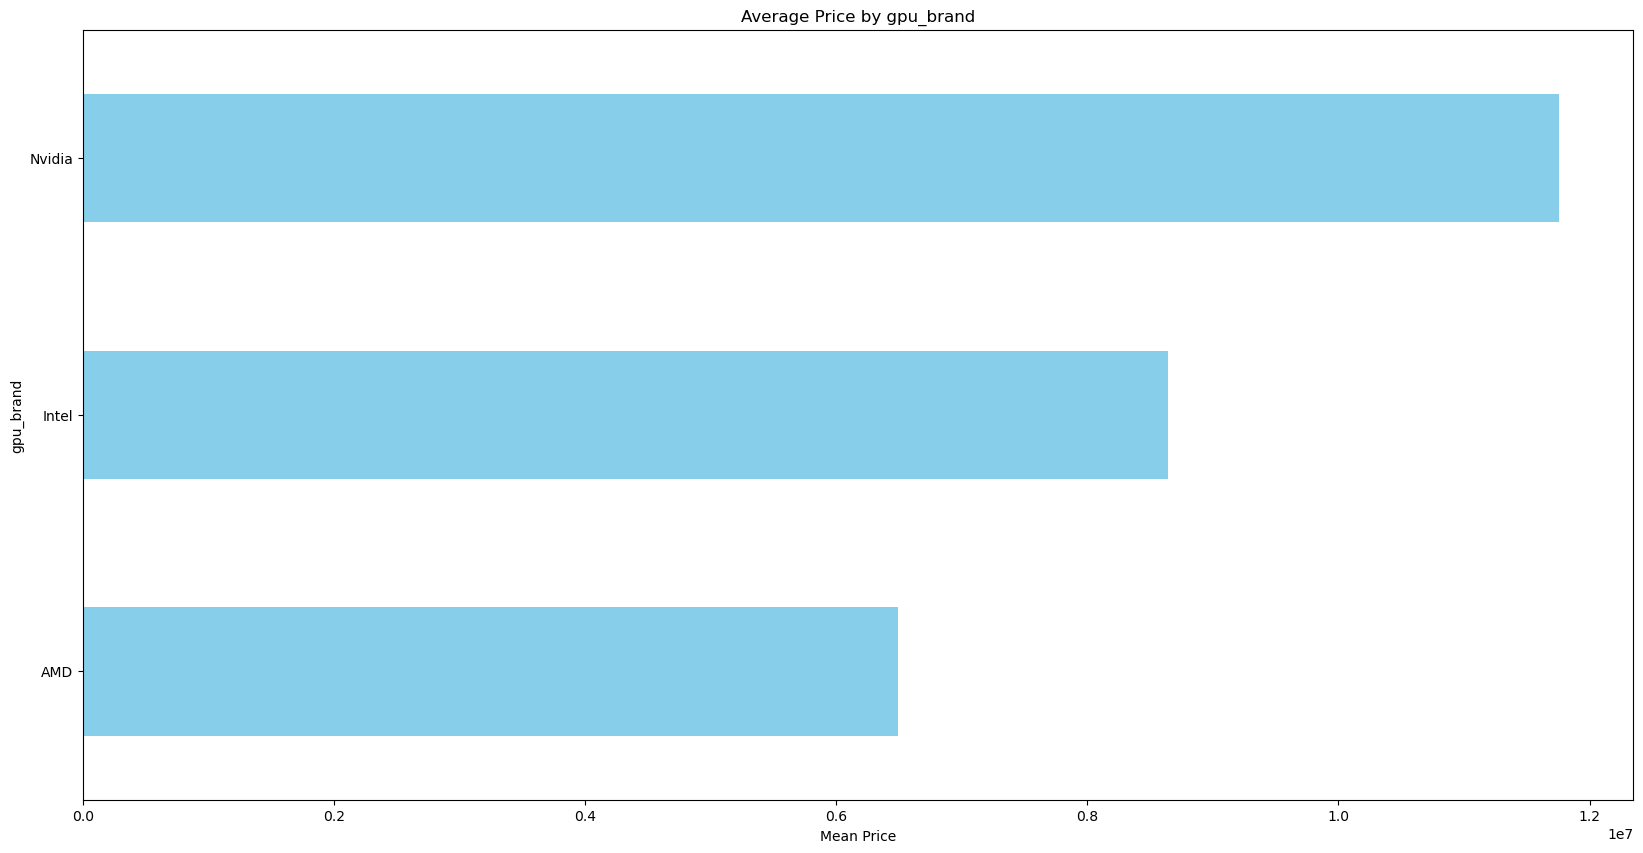

Average Price per Category in 'cpu_series':


cpu_series
Ryzen 1     1.498747e+07
i7          1.304749e+07
Core M      1.113278e+07
i5          8.719103e+06
A1          5.443100e+06
i3          4.794711e+06
A9          4.422248e+06
A8          3.986580e+06
Pentium     3.827010e+06
A6          3.599870e+06
A4          3.370068e+06
Celeron     2.827050e+06
E-Series    2.675494e+06
Atom        2.091043e+06
Name: price, dtype: float64

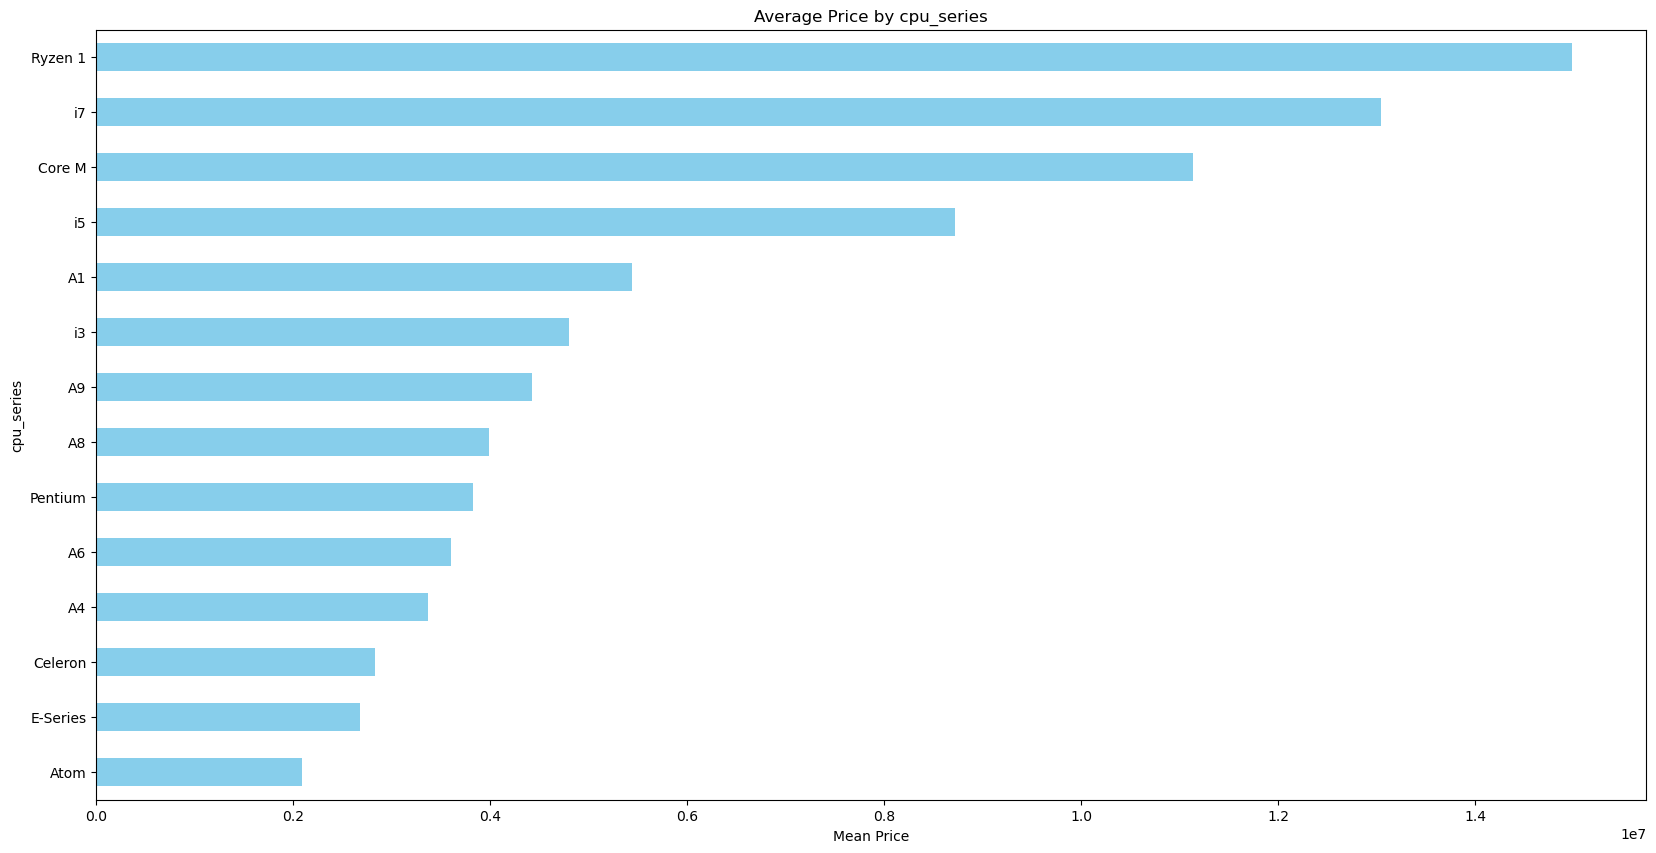

Average Price per Category in 'cpu_type':


cpu_type
Core M      1.113278e+07
Standard    1.022321e+07
A-Series    5.601249e+06
Pentium     3.827010e+06
Celeron     2.827050e+06
E-Series    2.675494e+06
Atom        2.091043e+06
Name: price, dtype: float64

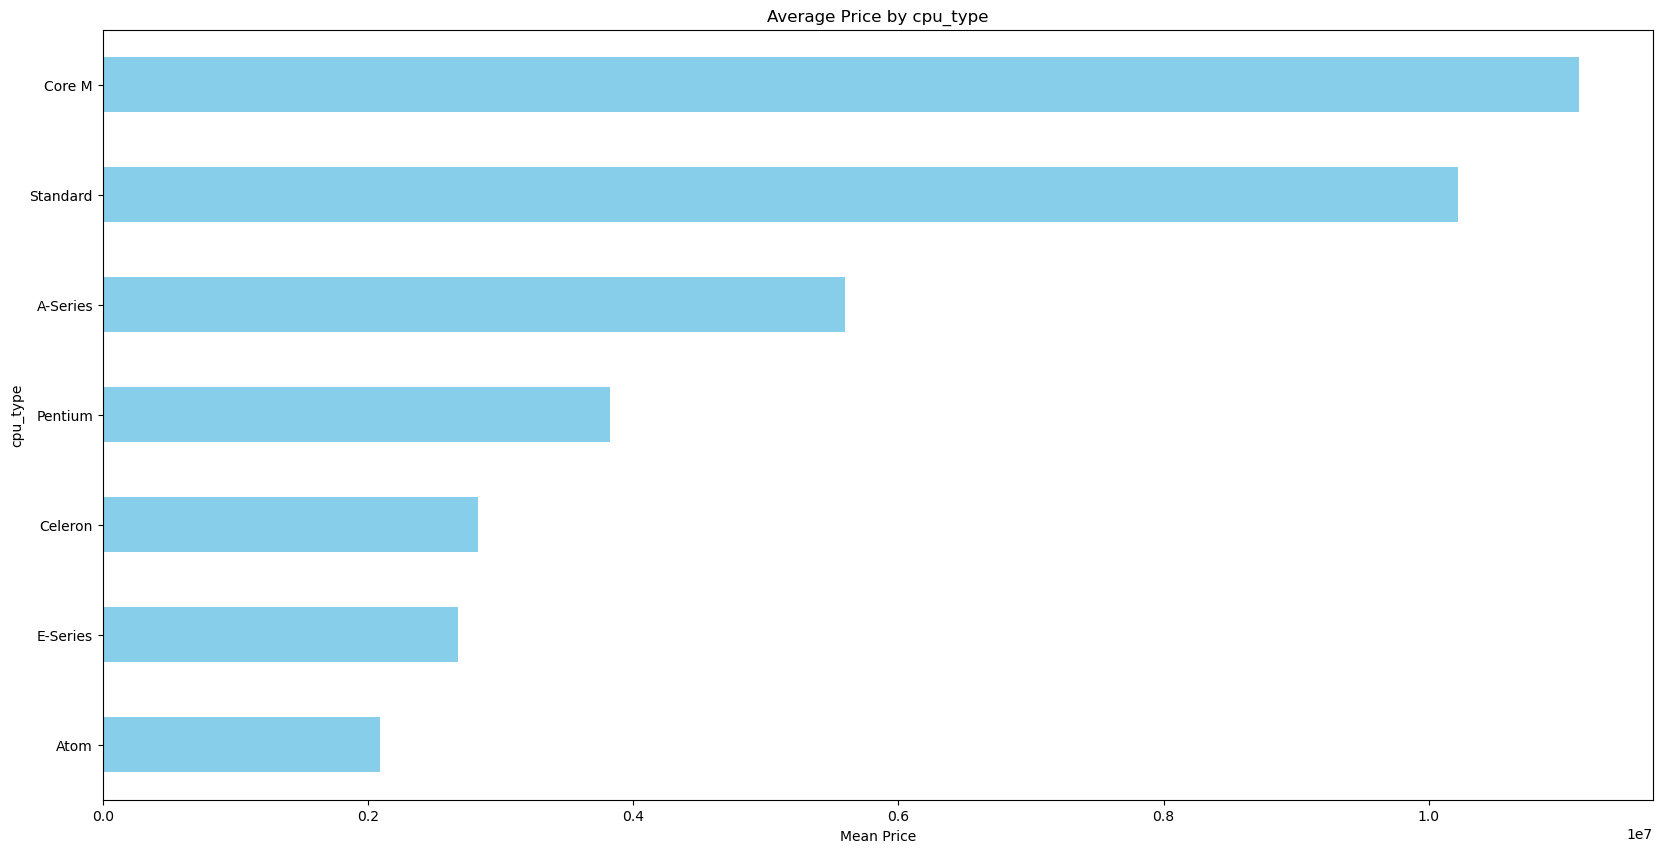

Average Price per Category in 'gpu_type':


gpu_type
Quadro M1200          2.150382e+07
GeForce GTX 1070      2.115399e+07
Quadro M2000M         2.107404e+07
Quadro M2200M         2.018039e+07
GeForce 960M          2.001305e+07
                          ...     
HD Graphics           3.357457e+06
HD Graphics 500       2.936642e+06
Radeon R2 Graphics    2.876562e+06
HD Graphics 400       2.642916e+06
Radeon R2             2.514640e+06
Name: price, Length: 85, dtype: float64

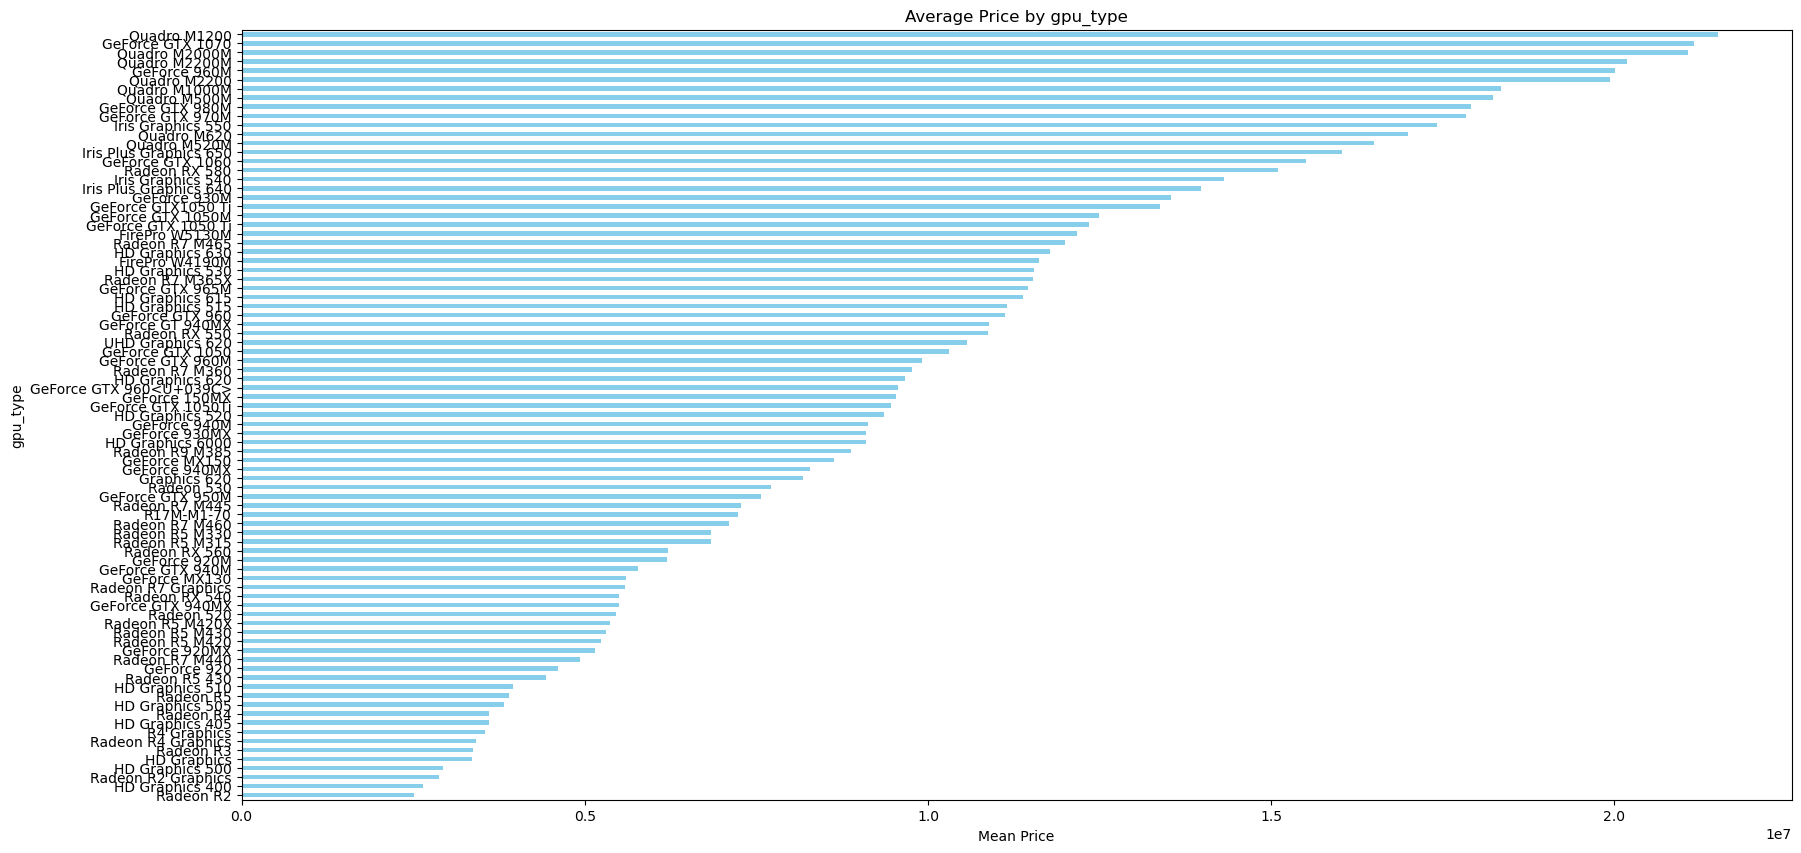

Average Price per Category in 'gpu_category':


gpu_category
Dedicated     9.662251e+06
Integrated    8.930591e+06
Name: price, dtype: float64

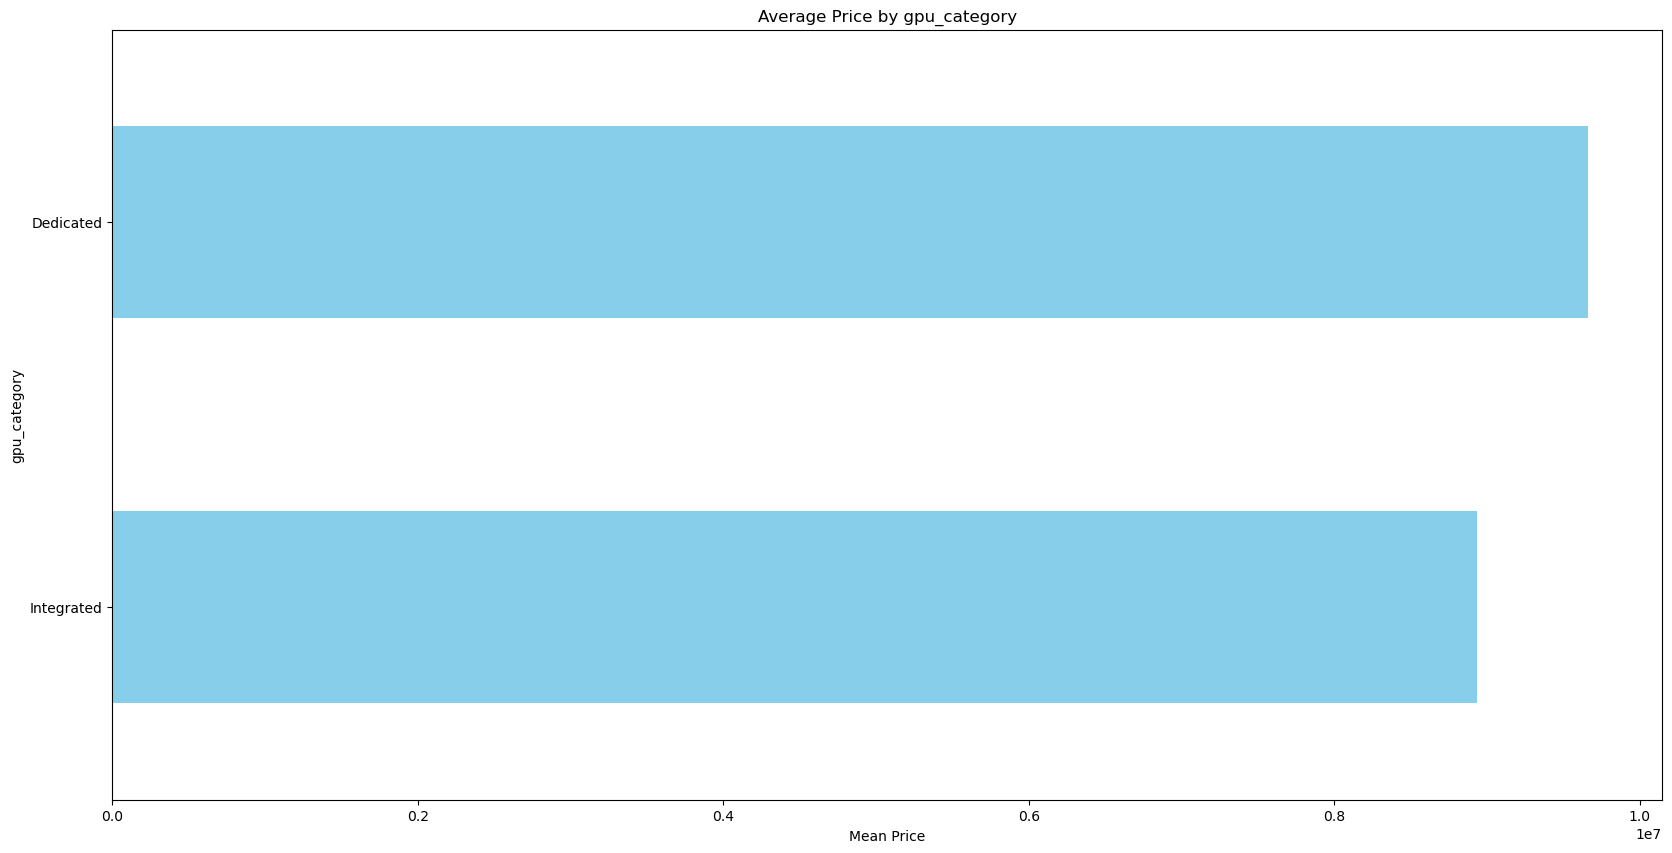

In [198]:
# Correlation values of the three attributes with Price

import matplotlib.pyplot as plt

for feature in cat_cols:
    print(f"Average Price per Category in '{feature}':")
    display(df_train_clean.groupby(feature)['price'].mean().sort_values(ascending=False))
    
    plt.figure(figsize=(20,10))
    df_train_clean.groupby(feature)['price'].mean().sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'Average Price by {feature}')
    plt.xlabel('Mean Price')
    plt.ylabel(feature)
    plt.show()

In [199]:
from scipy import stats



# Loop through categorical features and compute ANOVA
for feature in cat_cols:
    print(f"🔹 Feature: {feature}")
    # Group prices by the feature
    groups = df_train_clean.groupby(feature)['price'].apply(list)
    
    # Perform ANOVA F-test
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"   ➡ F-statistic: {f_stat:.4f}")
    print(f"   ➡ P-value: {p_value:.4e}")
    
    # Check significance
    if p_value < 0.05:
        print("   ✅ Significant relationship with Price")
    else:
        print("   ❌ Not significant")
    print("-" * 50)


🔹 Feature: manufacturer
   ➡ F-statistic: 10.3705
   ➡ P-value: 4.3432e-22
   ✅ Significant relationship with Price
--------------------------------------------------
🔹 Feature: model name
   ➡ F-statistic: 11.7397
   ➡ P-value: 4.1219e-131
   ✅ Significant relationship with Price
--------------------------------------------------
🔹 Feature: category
   ➡ F-statistic: 132.6137
   ➡ P-value: 4.2006e-107
   ✅ Significant relationship with Price
--------------------------------------------------
🔹 Feature: operating system
   ➡ F-statistic: 21.5830
   ➡ P-value: 1.5895e-20
   ✅ Significant relationship with Price
--------------------------------------------------
🔹 Feature: operating system version
   ➡ F-statistic: 7.6667
   ➡ P-value: 4.6499e-05
   ✅ Significant relationship with Price
--------------------------------------------------
🔹 Feature: resolution
   ➡ F-statistic: 72.4957
   ➡ P-value: 2.3258e-93
   ✅ Significant relationship with Price
---------------------------------------

In [200]:
df1['price'] = np.log(df1['price'])
df_test_clean['price'] = np.log(df_test_clean['price'])

In [201]:
df1 = df1.fillna('NaN')
df_test_clean = df_test_clean.fillna('NaN')

In [209]:
significant_cats = [
    'manufacturer','category', 
    'resolution','touchscreen',
    'storage_1_type', 'cpu_brand', 'gpu_brand', 
    'cpu_series','cpu_type',
]
significant_numeric = ['ram(GB)','cpu_freq(GHz)',
            'storage_1_gb', 'storage_2_gb','weight(kg)']


In [210]:
final_features = significant_cats + significant_numeric

# Create final datasets for modeling
X_train = df1[final_features].copy()
y_train = df1['price'].copy()

X_test = df_test_clean[final_features].copy()
y_test = df_test_clean['price'].copy()

print("✅ Final dataset ready for modeling:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

✅ Final dataset ready for modeling:
X_train shape: (975, 14)
y_train shape: (975,)


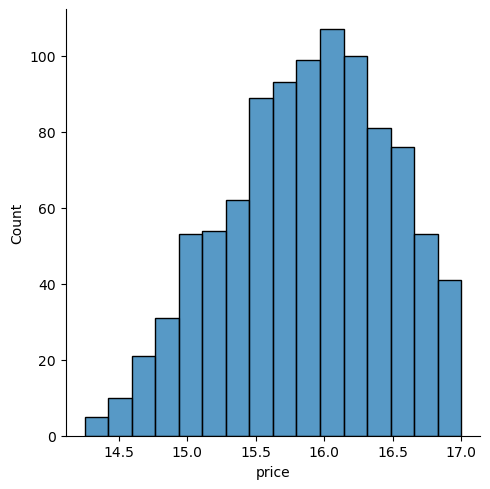

In [211]:
sns.displot(df1['price'])

## Modelling

In [212]:
!pip install lightgbm

In [216]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np


# ✅ Define categorical and numerical columns
cat_cols = significant_cats
num_cols = significant_numeric

# ✅ Create transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ✅ Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# ✅ Define all models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(max_depth=15, random_state=60),
    "Random Forest": RandomForestRegressor(n_estimators=400, max_depth=30, random_state=30),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, random_state=32),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.1, random_state=60),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.01, random_state=32),
    "Support Vector Regressor": SVR(kernel="rbf", C=10, epsilon=0.1)
}

# ✅ Store results
model_results = {}

# ✅ Train & Evaluate each model
for name, model in models.items():
    print(f"🔄 Training {name}...")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    model_results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"✅ {name}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

# ✅ Create comparison DataFrame
results_df = pd.DataFrame(model_results).T.sort_values("R2 Score", ascending=False)

# ✅ Display sorted results
print("\n📊 Model Comparison:")
print(results_df)


🔄 Training Linear Regression...
✅ Linear Regression: R² = 0.8091, RMSE = 0.2567
🔄 Training Ridge Regression...
✅ Ridge Regression: R² = 0.8165, RMSE = 0.2517
🔄 Training Lasso Regression...
✅ Lasso Regression: R² = 0.7566, RMSE = 0.2898
🔄 Training Decision Tree...
✅ Decision Tree: R² = 0.8121, RMSE = 0.2547
🔄 Training Random Forest...
✅ Random Forest: R² = 0.8779, RMSE = 0.2053
🔄 Training Gradient Boosting...
✅ Gradient Boosting: R² = 0.8840, RMSE = 0.2001
🔄 Training XGBoost...
✅ XGBoost: R² = 0.8786, RMSE = 0.2047
🔄 Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 975, number of used features: 39
[LightGBM] [Info] Start training from score 15.875300
✅ LightGBM: R² = 0.8524, RMSE = 0.2257
🔄 Training Sup

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 975, number of used features: 39
[LightGBM] [Info] Start training from score 15.875300


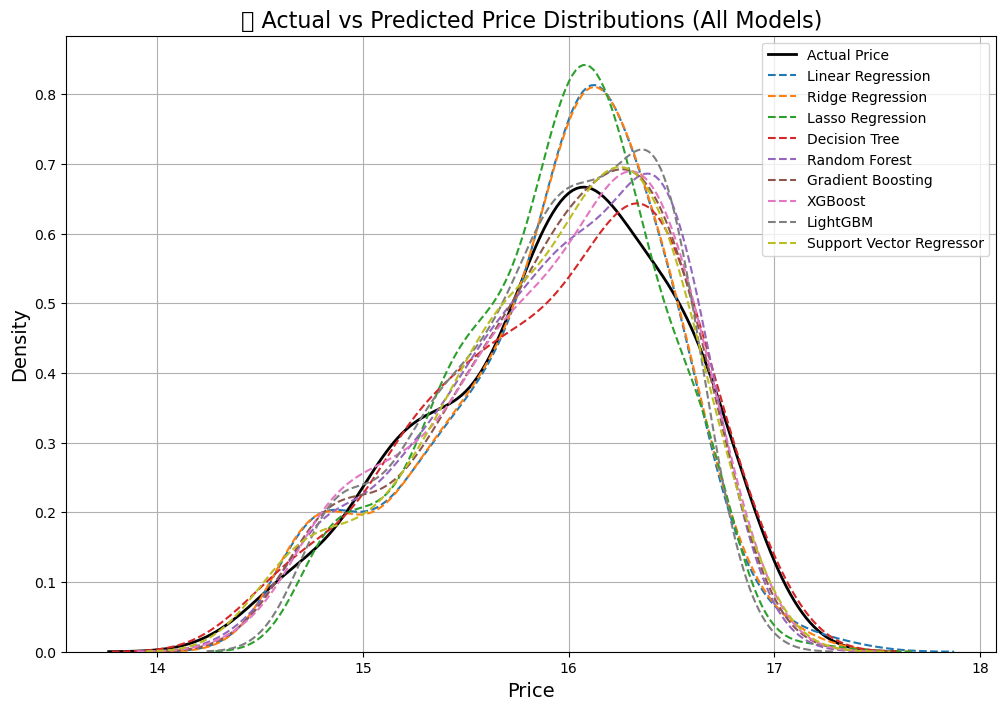

In [217]:


# ✅ Plot actual price distribution
plt.figure(figsize=(12, 8))
sns.kdeplot(y_test, label="Actual Price", color="black", linewidth=2)

# ✅ Add predicted price distributions for each model
for name, model in models.items():
    # Build the pipeline again for consistency
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Plot predicted distribution
    sns.kdeplot(y_pred, label=f"{name}", linestyle="--")

# ✅ Chart styling
plt.title("📊 Actual vs Predicted Price Distributions (All Models)", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


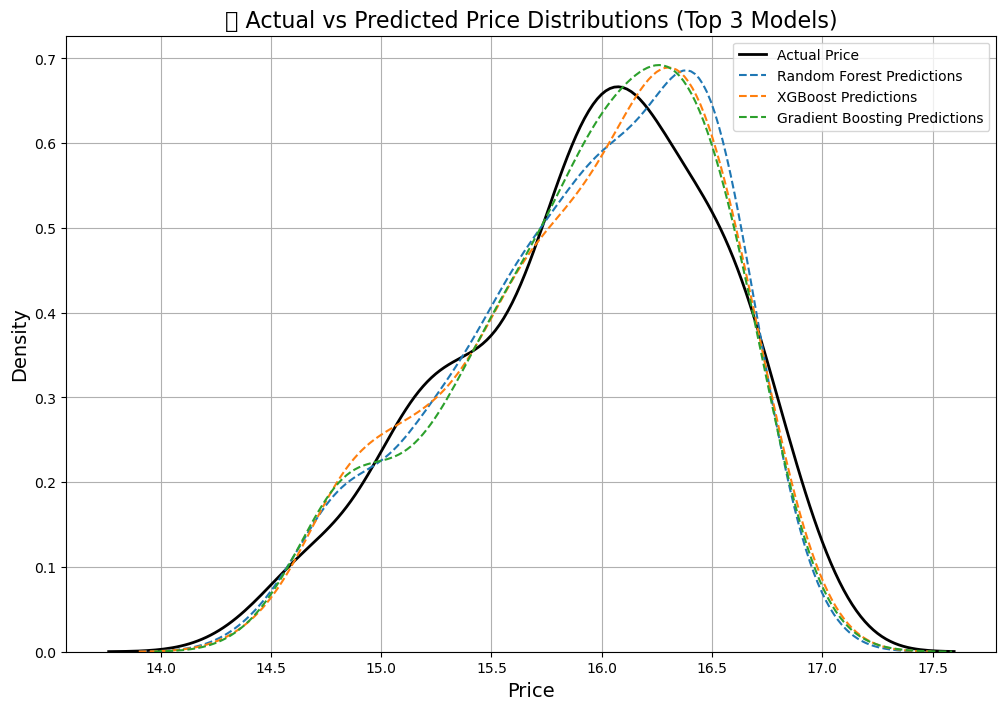

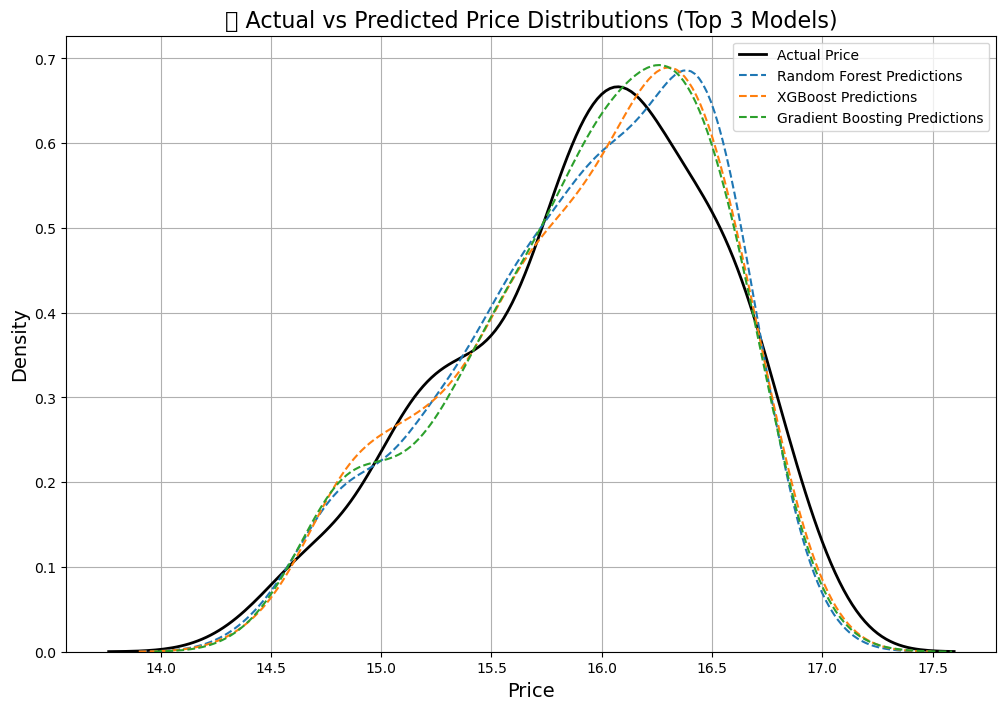

In [218]:

import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual price distribution
plt.figure(figsize=(12, 8))
sns.kdeplot(y_test, label="Actual Price", color="black", linewidth=2)

# Top 3 models
top_models = ["Random Forest", "XGBoost", "Gradient Boosting"]

# Add predicted price distributions for top models
for name in top_models:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[name])
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    sns.kdeplot(y_pred, label=f"{name} Predictions", linestyle="--")

# Chart styling
plt.title("📊 Actual vs Predicted Price Distributions (Top 3 Models)", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

# Plot actual price distribution
plt.figure(figsize=(12, 8))
sns.kdeplot(y_test, label="Actual Price", color="black", linewidth=2)

# Top 3 models
top_models = ["Random Forest", "XGBoost", "Gradient Boosting"]

# Add predicted price distributions for top models
for name in top_models:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[name])
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    sns.kdeplot(y_pred, label=f"{name} Predictions", linestyle="--")

# Chart styling
plt.title("📊 Actual vs Predicted Price Distributions (Top 3 Models)", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


In [220]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

#  Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, significant_numeric),
    ('cat', categorical_transformer, significant_cats)
])

# Models to tune
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

#  Hyperparameter grids for RandomizedSearchCV
param_distributions = {
    'Random Forest': {
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__gamma': [0, 1, 5]
    }
}

# Dictionary to store results
tuning_results = {}

# Run RandomizedSearchCV for each model
for name, model in models.items():
    print(f"Tuning {name} with RandomizedSearchCV...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[name],
        n_iter=20,  # Try 20 random combinations
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=2,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    
    # Store best parameters and scores
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    tuning_results[name] = {
        'Best Params': random_search.best_params_,
        'R2 Score': r2,
        'RMSE': rmse
    }
    
    print(f"{name} RandomizedSearchCV Done")
    print(f"Best R²: {r2:.4f}, RMSE: {rmse:.4f}\n")

# Show Results
import pandas as pd

results_df = pd.DataFrame(tuning_results).T
print("\n RandomizedSearchCV Results:")
print(results_df)

# Pick the best model for GridSearchCV fine-tuning
best_model_name = results_df['R2 Score'].idxmax()
print(f"\n Best Model After RandomizedSearchCV: {best_model_name}")

# Fine-tune the best model with GridSearchCV
print(f"\nFine-tuning {best_model_name} with GridSearchCV...")

best_model = models[best_model_name]
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Use narrowed parameter grid for fine-tuning
grid_params = param_distributions[best_model_name]  # You can narrow this further
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Final evaluation
final_best_model = grid_search.best_estimator_
y_pred_final = final_best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f" Fine-Tuned {best_model_name} Results:")
print(f"Best Params: {grid_search.best_params_}")
print(f"R² Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.4f}")


Tuning Random Forest with RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10